In [ ]:
import pandas as pd
import numpy as np
import warnings
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.feature_selection import mutual_info_classif
from scipy.stats import chi2_contingency
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.model_selection import  cross_val_predict
from sklearn.metrics import classification_report
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import RobustScaler
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import FeatureUnion
from sklearn.impute import MissingIndicator
from sklearn.feature_selection import SelectFromModel
from sklearn.metrics import f1_score
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform
import os
import glob
import joblib
from sklearn.metrics import confusion_matrix

warnings.filterwarnings('ignore')

In [2]:
#Models of interest
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import roc_curve, roc_auc_score
import joblib

import torch 
import torch.nn as nn

In [3]:
df = pd.read_csv("Post_EDA_data.csv")
df.head()

,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,emp_length,home_ownership,...,hardship_end_date,payment_plan_start_date,hardship_length,hardship_dpd,hardship_loan_status,orig_projected_additional_accrued_interest,hardship_payoff_balance_amount,hardship_last_payment_amount,debt_settlement_flag,y
0,12000.0,12000.0,12000.0,36 months,7.97%,375.88,A,A5,10+ years,OWN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,1
1,32000.0,32000.0,32000.0,36 months,11.99%,1062.71,B,B5,10+ years,MORTGAGE,...,Jun-2020,Apr-2020,2.0,0.0,ACTIVE,123.08000,6189.66,1062.71,N,1
2,40000.0,40000.0,40000.0,60 months,15.05%,952.65,C,C4,9 years,MORTGAGE,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,1
3,16000.0,16000.0,16000.0,36 months,7.97%,501.17,A,A5,5 years,RENT,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,1
4,33000.0,33000.0,33000.0,36 months,7.21%,1022.12,A,A3,< 1 year,MORTGAGE,...,Apr-2020,Feb-2020,3.0,21.0,DELINQUENT,177.96231,10197.78,59.68,N,0


In [4]:
df.shape

(2029952, 131)

In [5]:
class Feature_engineering_step(BaseEstimator,TransformerMixin):
    def __init__(self,date_cols):
        self.date_cols = date_cols


    def fit(self,X,y=None):
        X= X.copy()

        # Make sure date columns are actually datetime
        for col in self.date_cols:
            X[col] = pd.to_datetime(X[col], errors="coerce")

        self.current_t_ = X[self.date_cols].max().max()
        return self
    
    def transform(self,X):
        X = X.copy()

        for col in self.date_cols:
            X[col] = pd.to_datetime(X[col], errors="coerce")

        X["customer_history"] = (X['issue_d'] - X["earliest_cr_line"]).dt.days
        X["months_since_earliest_credit_line"] = (
            (self.current_t_.year - X["earliest_cr_line"].dt.year) * 12
            + (self.current_t_.month - X["earliest_cr_line"].dt.month)
        )

        X["loan_age_months"] = ((self.current_t_.year - X["issue_d"].dt.year) * 12
                                + (self.current_t_.month - X["issue_d"].dt.month))
        
        X["current_balance_ratio"] = (
            X["out_prncp"] / X["loan_amnt"].replace(0, np.nan)
        )

        X["payment_progress_ratio"] = (
            X["total_rec_prncp"] / X["loan_amnt"].replace(0, np.nan)
        )

        X = X.drop(columns=self.date_cols)

        X["term_months"] = X["term"].str.extract("(\d+)").astype(float)

        emp_length_map = {
    "< 1 year": 0,
    "1 year": 1,
    "2 years": 2,
    "3 years": 3,
    "4 years": 4,
    "5 years": 5,
    "6 years": 6,
    "7 years": 7,
    "8 years": 8,
    "9 years": 9,
    "10+ years": 10
    }

        X["emp_length_num"] = X["emp_length"].map(emp_length_map)

        X["int_rate"] = X["int_rate"].astype(str).str.replace("%", "", regex=False).astype(float)
        X["revol_util"] = X["revol_util"].astype(str).str.replace("%", "", regex=False).astype(float)

        # Drop original text versions
        X = X.drop(columns=["term", "emp_length"])


        return X


In [6]:
date_cols = ["issue_d", "last_pymnt_d", "last_credit_pull_d", "next_pymnt_d", "earliest_cr_line"]

In [7]:
#self.Q1_ saves the learned threshold from training so it can be consistently applied to new data.
class OutlierFlaggerv2(BaseEstimator, TransformerMixin):
    #Sklearn pipeline uses both x and y so thus we add y=None
    def fit(self,X, y=None):
        #To keep track of the columns
        X = pd.DataFrame(X)
        X.columns = X.columns.astype(str)
        self.feature_names_in_ = list(X.columns)
        self.Q1 = X.quantile(0.25)
        self.Q3 = X.quantile(0.75)
        self.IQR = self.Q3 - self.Q1
        #Return the capsulated info obtained
        return self

    def transform(self,X):
        X = pd.DataFrame(X, columns=self.feature_names_in_)
        X.columns = X.columns.astype(str)
        lower = self.Q1 -  1.5*self.IQR
        upper = self.Q3 +  1.5*self.IQR
        flags = ((X < lower) |(X>upper)).astype(int)
        #We keep the original feature and add a new column to capture outlier information, not replace it.

        flags.columns = [str(col) + "_outlier" for col in X.columns]
        
        return flags
    
    def get_feature_names_out(self, input_features=None):
        if input_features is None:
            #Store the input features in a variable, then to a list
            input_features = self.feature_names_in_
        input_features = [str(col) for col in input_features]
        outlier_names = [col + "_outlier" for col in input_features]
        return np.array(outlier_names, dtype=object)

In [8]:
class Missing_val_dropper(BaseEstimator,TransformerMixin):
    def __init__(self, threshold = 50.0):
        self.threshold = threshold

    def fit(self,X,y=None):
        #learns the columns to drop
        X = pd.DataFrame(X).copy()

        #Missing percent vector that holds the missing percentage indexed by the col names
        missing_percent = X.isna().mean() * 100

        #Columns with  >= threshold missigness
        self.columns_to_drop = missing_percent[missing_percent >= self.threshold].index.tolist()

        self.feature_names = X.columns.tolist()
        return self
    
    def transform(self,X):
        #actually drops the columns
        X = pd.DataFrame(X).copy()
        return X.drop(columns=self.columns_to_drop,errors="ignore")
    
    def get_feature_names_out(self, input_features=None):
        if input_features is None:
            input_features = self.feature_names

        return np.array([
            col for col in input_features
            if col not in self.columns_to_drop
        ])

## Cross Validation

In [9]:
#Divide from X and y
X = df.drop("y", axis=1)
y= df["y"]

In [10]:
#Dropped after seeing it was data leakage
X.drop(["recoveries","collection_recovery_fee"],axis=1, inplace=True)
#recoveries is the money recovered after a loan has defaulted.
#collection_recovery_fee is the cost charged for collecting that recovered money.


In [11]:
leakage_cols = [
    "out_prncp_inv",
    "total_rec_late_fee",
    "last_pymnt_amnt",
    "debt_settlement_flag",
    "total_pymnt",
    "total_pymnt_inv",
    "total_rec_int"
]
X.drop(leakage_cols,axis=1,inplace=True)

In [12]:
#Hardship flag removal since it indicates if the borrower is haviung trouble paying
X.drop("hardship_flag",axis=1,inplace=True)

In [13]:
#subsample a subset of the data
X_sub = X.sample(n=200000, random_state=42)
y_sub = y.loc[X_sub.index]

In [14]:
# train/temp split
X_train, X_temp, y_train, y_temp = train_test_split(
    X_sub, y_sub,
    test_size=0.30,
    random_state=42,
    stratify=y_sub
)

#validation/test split
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

'''
Ideally we end up with
70% train
15% validation
15% test
'''

'\nIdeally we end up with\n70% train\n15% validation\n15% test\n'

In [15]:
X_train.shape

(140000, 120)

In [16]:
X_val.shape

(30000, 120)

In [17]:
numerical_columns = X.select_dtypes(include="number", exclude=["category","object"]).columns
Cat_columns = X.select_dtypes(include=["object","category"]).columns

In [18]:
#Sample the numerical columns only from the training data
X_sample = X_train.sample(n=5000, random_state=42)
y_sample = y_train.loc[X_sample.index]

In [19]:
#Only numerical columns
X_num_sample = X_sample[numerical_columns]
X_num_sample.head()

,loan_amnt,funded_amnt,funded_amnt_inv,installment,annual_inc,dti,delinq_2yrs,fico_range_low,fico_range_high,inq_last_6mths,...,sec_app_num_rev_accts,sec_app_chargeoff_within_12_mths,sec_app_collections_12_mths_ex_med,deferral_term,hardship_amount,hardship_length,hardship_dpd,orig_projected_additional_accrued_interest,hardship_payoff_balance_amount,hardship_last_payment_amount
1308177,5000.0,5000.0,5000.0,179.69,20000.0,35.29,0.0,735.0,739.0,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
690673,37600.0,37600.0,37600.0,1164.60,325000.0,12.62,1.0,770.0,774.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
568761,9000.0,9000.0,9000.0,290.75,33000.0,27.71,0.0,675.0,679.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1425531,28000.0,28000.0,27900.0,658.21,121400.0,5.07,0.0,755.0,759.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1588854,28000.0,28000.0,28000.0,780.52,110000.0,14.87,5.0,665.0,669.0,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [20]:
fe = Feature_engineering_step(date_cols=date_cols)

X_train_fe = fe.fit_transform(X_train)
X_val_fe = fe.transform(X_val)
X_test_fe = fe.transform(X_test)

In [21]:
numerical_columns_train_recalculated = X_train_fe.select_dtypes(include=["int64", "float64"]).columns.tolist()

Cat_columns_train_recaulciated = X_train_fe.select_dtypes(include=["object", "category"]).columns.tolist()

## PCA & t-nse

In [22]:
#Consruct the numerical pipeline and fit transform
#Try standard scaler and Robust
num_only_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median", add_indicator=True)),
    ("scaler", RobustScaler())
])

X_num_processed = num_only_pipe.fit_transform(X_num_sample)

In [23]:
#Do PCA on the trimmed data
pca = PCA(n_components=30, random_state=42)
X_pca = pca.fit_transform(X_num_processed)

In [24]:
#Apply t-nse
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
X_tsne = tsne.fit_transform(X_pca)

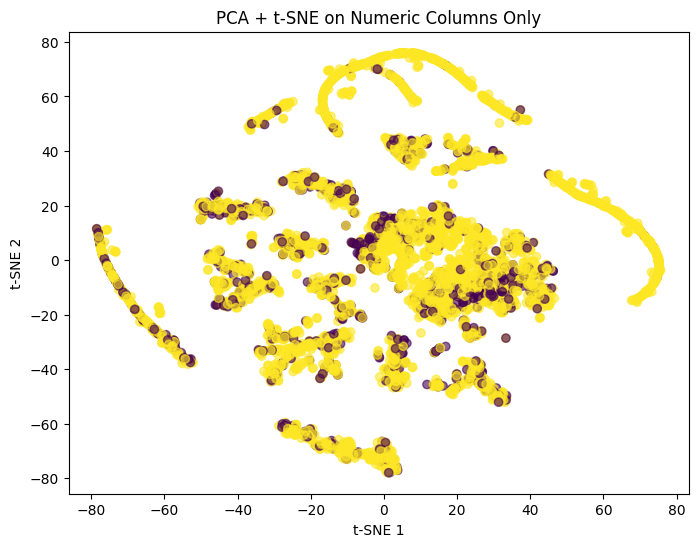

In [25]:
plt.figure(figsize=(8, 6))
plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=y_sample, alpha=0.6)
plt.title("PCA + t-SNE on Numeric Columns Only")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.show()

## ---------------------------

## Pipeline creation & post-transformation evaluation & Univariate variable selection

Block of code below assesses the multicollinearity between 2 numerical independent variables. If it is above a certain threshold we remove the one with less mutual information

In [26]:
#Version to fit into the pipeline
class CorrelationFeatureSelector(BaseEstimator,TransformerMixin):
    def __init__(self, threshold=0.80):
        self.threshold = threshold

    def fit(self,X,y=None):
        X = pd.DataFrame(X)

        corr_matrix = X.corr(numeric_only=True).abs()

        mask = np.triu(np.ones_like(corr_matrix), k=1).astype(bool)
        upper = corr_matrix.where(mask)

        #Use the set to not collect duplicates
        columns_to_drop = set()

        for col in upper.columns:
            for row in upper.index:
                if upper.loc[row,col] > self.threshold and pd.notna(upper.loc[row, col]):
                    #mutual info needs to be 2d inputted
                    mi_row = mutual_info_classif(X[[row]],y,random_state=45)
                    mi_col = mutual_info_classif(X[[col]],y,random_state=45)
                    #reminder larger values means stronger association
                    if mi_row[0] >= mi_col[0]:
                        columns_to_drop.add(col)
                    else:
                        columns_to_drop.add(row)
        self.columns_to_drop = list(columns_to_drop)
        self.feature_names = list(X.columns)

        return self
    
    def transform(self,X):
        X = pd.DataFrame(X,columns=self.feature_names)
        return X.drop(columns=self.columns_to_drop,errors="ignore")
    
    def get_feature_names_out(self, input_features=None):
        if input_features is None:
            input_features = self.feature_names

        return np.array(
            [col for col in input_features if col not in self.columns_to_drop],
            dtype=object
        )


In [27]:
def cramers_V(x,y):
    '''
    Here we calculate the Cramer's V to asses the strength of association between 2 nominal variables
    '''
    table =pd.crosstab(x,y)
    #Extract only the chi-square statistics
    chi2=chi2_contingency(table)[0]
    n = table.sum().sum()
    r,k = table.shape
    return np.sqrt(chi2 / (n*(min(r,k) -1)))

In [28]:
#Version to fit into the pipeline
class CategoricalFeatureSelector(BaseEstimator,TransformerMixin):
    def __init__(self, threshold=0.80):
        self.threshold = threshold

    def fit(self,X,y=None):
        X = pd.DataFrame(X)
        self.feature_names = list(X.columns)

        to_drop = set()

        for i in range(len(self.feature_names)):
            for j in range(i + 1, len(self.feature_names)):
                col1 = self.feature_names[i]
                col2 = self.feature_names[j]
                
                v = cramers_V(X[col1], X[col2])
                
                if v > self.threshold:
                    # compare usefulness with target using mutual info
                    x1_encoded = pd.factorize(X[col1])[0].reshape(-1, 1)
                    x2_encoded = pd.factorize(X[col2])[0].reshape(-1, 1)

                    mi1 = mutual_info_classif(x1_encoded, y, discrete_features=True, random_state=45)
                    mi2 = mutual_info_classif(x2_encoded, y, discrete_features=True, random_state=45)
                    
                    if mi1[0] >= mi2[0]:
                        to_drop.add(col2)
                    else:
                        to_drop.add(col1)
        self.columns_to_drop= list(to_drop)
        return self
    
    def transform(self, X):
        X = pd.DataFrame(X).copy()
        X = X.drop(columns=self.columns_to_drop, errors="ignore")
        return X

    def get_feature_names_out(self, input_features=None):
        if input_features is None:
            input_features = self.feature_names

        input_features = np.array(input_features)

        return np.array([
            col for col in input_features
            if col not in self.columns_to_drop
        ])


## Variable Selection via tree-based model

## Model selection

Here is the list of models, that are a candidate pool of models
* (FFN) Feed forward Nueral Network
* Logistic regression
* Xg Boost
* random forest

Maybe change from standard scaler to robust scaler

In [29]:
def model_summary(fitted_model, X_val,y_val,model_name):
    #Predicted probabilities for DV of 0
    y_probs = fitted_model.predict_proba(X_val)[:,0]
    y_pred = fitted_model.predict(X_val)

    class_report = classification_report(y_val,y_pred)
    # ROC values
    fpr, tpr, thresholds = roc_curve(y_val, y_probs, pos_label=0)

    # AUC
    auc = roc_auc_score(1-y_val, y_probs)

    plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
    #Baseline
    plt.plot([0, 1], [0, 1], linestyle='--') 
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve of DV=0")
    plt.legend()
    plt.show()


    print(class_report)
    print(f"current model auc:{auc:3f}")
    print(f"current model name:{model_name}")

In [30]:
numerical_columns_train = X_train.select_dtypes(include="number", exclude=["category","object"]).columns
Cat_columns_train = X_train.select_dtypes(include=["object","category"]).columns

In [31]:
def Youden_threshold(fitted_model, X_val, y_val):
    
    # Probability of original class 0
    y_probs = fitted_model.predict_proba(X_val)[:, 0]

    # Treat original class 0 as the positive class
    fpr, tpr, thresholds = roc_curve(y_val, y_probs, pos_label=0)

    j_scores = tpr - fpr
    best_idx = np.argmax(j_scores)
    j_threshold = thresholds[best_idx]

    print(f"Youden threshold for class 0: {j_threshold}")
    
    # Predict class 0 if probability of class 0 is above threshold
    y_pred_changed = np.where(y_probs >= j_threshold, 0, 1)
   
    print("Classification report with threshold")
    print(classification_report(y_val, y_pred_changed))

    return j_threshold

In [32]:
def f1_threshold(fitted_model, X_val, y_val):

    # Probability of class 0
    y_probs_0 = fitted_model.predict_proba(X_val)[:, 0]

    thresholds = np.linspace(0, 1, 100)
    f1_scores = []

    for t in thresholds:
        # Predict class 0 if probability of class 0 >= threshold
        y_pred = np.where(y_probs_0 >= t, 0, 1)

        # F1 score for class 0
        score = f1_score(y_val, y_pred, pos_label=0)
        f1_scores.append(score)

    best_idx = np.argmax(f1_scores)
    optimal_threshold = thresholds[best_idx]

    print(f"F1 optimal threshold for class 0: {optimal_threshold}")

    y_pred_optimal = np.where(y_probs_0 >= optimal_threshold, 0, 1)

    print("Classification report with threshold")
    print(classification_report(y_val, y_pred_optimal))

    return optimal_threshold

In [33]:
from sklearn.metrics import recall_score, precision_score


def recall_threshold(fitted_model, X_val, y_val):

    # Probability of class 0
    y_probs_0 = fitted_model.predict_proba(X_val)[:, 0]

    thresholds = np.linspace(0, 1, 100)
    recall_scores = []

    for t in thresholds:
        # Predict class 0 if probability of class 0 >= threshold
        y_pred = np.where(y_probs_0 >= t, 0, 1)

        # Recall score for class 0
        score = recall_score(y_val, y_pred, pos_label=0)
        recall_scores.append(score)

    best_idx = np.argmax(recall_scores)
    optimal_threshold = thresholds[best_idx]

    print(f"Recall optimal threshold for class 0: {optimal_threshold}")

    y_pred_optimal = np.where(y_probs_0 >= optimal_threshold, 0, 1)

    print("Classification report with threshold")
    print(classification_report(y_val, y_pred_optimal))

    return optimal_threshold

In [34]:
from sklearn.preprocessing import FunctionTransformer

to_dense = FunctionTransformer(
    lambda x: x.toarray() if hasattr(x, "toarray") else x
)

to_float = FunctionTransformer(
    lambda x: x.astype(np.float32)
)

In [35]:
models_of_interest =[
("Logistic Regression",LogisticRegression(max_iter=1000)),
("Random Forest",RandomForestClassifier(n_estimators=200,random_state=42)),
("XG Boost",XGBClassifier())
]

Research Goal: Can we predict whether a LendingClub loan is in good standing based on the borrower’s current financial and credit profile?

## Preprocessing & feature selection pipeline

## -----------------------------------------------------------

# Baseline with the added missing_val_droppers

In [36]:

#I barely added the missing indicator when it should have been in the beggining 5/14. Will use it for the final model evaluation
categorical_pipeline = Pipeline([
    ("drop_missing_cols", Missing_val_dropper(threshold=50.0)),
    ("imputer", SimpleImputer(strategy="constant", fill_value="missing", add_indicator=True)),
    ("cat_selector", CategoricalFeatureSelector(threshold=0.80)),
    ("onehot", OneHotEncoder(drop="first", handle_unknown="ignore", sparse_output=False))
])

numerical_pipeline = Pipeline([
    ("drop_missing_cols", Missing_val_dropper(threshold=50.0)),
    ("imputer", SimpleImputer(strategy="median", add_indicator=True)),
    ("outlier", OutlierFlaggerv2()),
    ("scaler", RobustScaler())
])

In [37]:
# 2. Recalculate column types after feature engineering
numerical_columns_train_fe = X_train_fe.select_dtypes(
    include=["int64", "float64", "int32", "float32"]
).columns.tolist()

categorical_columns_train_fe = X_train_fe.select_dtypes(
    include=["object", "category", "bool"]
).columns.tolist()

In [38]:
preprocessing = ColumnTransformer([
    ("cat", categorical_pipeline, categorical_columns_train_fe),
    ("num", numerical_pipeline, numerical_columns_train_fe)
], remainder="passthrough")

X_processed = preprocessing.fit_transform(X_train_fe, y_train)

# PCA before t-SNE
pca = PCA(n_components=30, random_state=42)
X_pca = pca.fit_transform(X_processed)

# t-SNE
tsne = TSNE(
    n_components=2,
    perplexity=30,
    random_state=42,
    init="pca",
    learning_rate="auto"
)

X_tsne = tsne.fit_transform(X_pca)

plt.figure(figsize=(8, 6))
plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=y_train, alpha=0.6)
plt.title("PCA + t-SNE on Preprocessed Training Data")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.show()

In [39]:
baseline_pipeline = Pipeline([
    ("process", preprocessing),
    ("corr_selector", CorrelationFeatureSelector(threshold=0.80)),
    ("tree_selector", SelectFromModel(
        RandomForestClassifier(n_estimators=300, random_state=42),
        threshold="mean"
    )),
    ("model", LogisticRegression(max_iter=1000))
])

In [40]:
#Baseline with PCA
#deleted the feature engineering process friom here because of the amount of time it took fro tone fit
baseline_pipeline_pca = Pipeline([
    ("process", preprocessing),
    ("corr_selector", CorrelationFeatureSelector(threshold=0.80)),
    ("tree_selector", SelectFromModel(
        RandomForestClassifier(n_estimators=1000, random_state=42),
        threshold="mean"
    )),
    ("pca", PCA(n_components=30, random_state=42)),
    ("model", LogisticRegression(max_iter=1000))
])

In [41]:
baseline_pipeline.fit(X_train_fe, y_train)

,steps,"[('process', ...), ('corr_selector', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat', ...), ('num', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


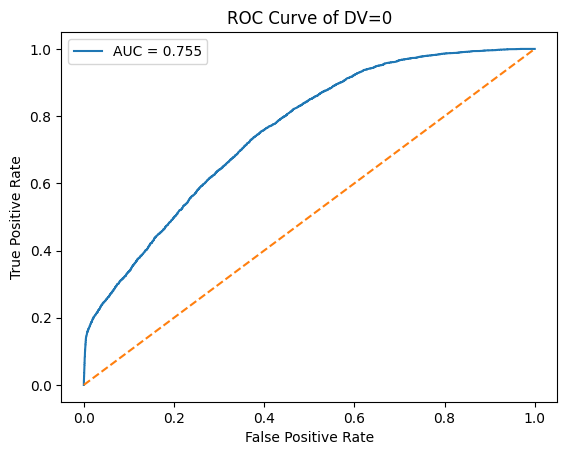

              precision    recall  f1-score   support

           0       0.81      0.15      0.25      4822
           1       0.86      0.99      0.92     25178

    accuracy                           0.86     30000
   macro avg       0.84      0.57      0.59     30000
weighted avg       0.85      0.86      0.81     30000

current model auc:0.754689
current model name:base


In [42]:
model_summary(baseline_pipeline, X_val_fe, y_val, "base")

## -----------------------------------------------------------

In [43]:


def recall_threshold_with_min_precision(fitted_model, X_val, y_val, min_precision=0.40):

    y_probs_0 = fitted_model.predict_proba(X_val)[:, 0]
    thresholds = np.linspace(0.01, 0.99, 100)

    best_threshold = None
    best_recall = -1

    for t in thresholds:
        y_pred = np.where(y_probs_0 >= t, 0, 1)

        precision = precision_score(y_val, y_pred, pos_label=0, zero_division=0)
        recall = recall_score(y_val, y_pred, pos_label=0, zero_division=0)

        if precision >= min_precision and recall > best_recall:
            best_recall = recall
            best_threshold = t

    if best_threshold is None:
        print(f"No threshold found with class 0 precision >= {min_precision}")
        return None

    print(f"Best threshold for class 0 recall with precision >= {min_precision}: {best_threshold}")

    y_pred_optimal = np.where(y_probs_0 >= best_threshold, 0, 1)

    print("Classification report with threshold")
    print(classification_report(y_val, y_pred_optimal))

    return best_threshold

In [44]:
recall_threshold_with_min_precision(baseline_pipeline, X_val_fe, y_val)

Best threshold for class 0 recall with precision >= 0.4: 0.24757575757575756
Classification report with threshold
              precision    recall  f1-score   support

           0       0.40      0.33      0.36      4822
           1       0.88      0.91      0.89     25178

    accuracy                           0.81     30000
   macro avg       0.64      0.62      0.63     30000
weighted avg       0.80      0.81      0.81     30000



np.float64(0.24757575757575756)

## Pipeline name extraction

## Slightly more complex model selection

In [45]:
from sklearn.metrics import make_scorer, f1_score

#to make a score that is f1, score but to detect it on the minority cl asss 0
f1_class_0 = make_scorer(f1_score, pos_label=0)

In [46]:
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE, RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler

In [47]:
pipe = Pipeline([
    ("preprocess", preprocessing),
    ("corr_selector", CorrelationFeatureSelector(threshold=0.80)),
    ("tree_selector", SelectFromModel(
        RandomForestClassifier(n_estimators=300, random_state=42),
        threshold="mean"
    )),
    ("sampler", "passthrough"),
    ("model", LogisticRegression(max_iter=1000))
])

In [48]:
n_class_0 = (y_train == 0).sum()
n_class_1 = (y_train == 1).sum()

n_class_0, n_class_1
scale_pos_weight = n_class_0 / n_class_1

In [51]:
param_XGB_sampler = [
    #Note to self 5/11: try with smote
    #Each dictionary value is for each model set up, like for example each differnt versions of Logistic regression are based on the different model penalties, and not all can use other model penalties
    

    # XGBoost
    {
        "preprocess__num__drop_missing_cols__threshold": [50, 60, 70, 80, 90],
        "preprocess__cat__drop_missing_cols__threshold": [50, 60, 70, 80, 90],
        "sampler": [
    
    # Undersampling
    # RandomUnderSampler(sampling_strategy=0.30, random_state=42),
    # RandomUnderSampler(sampling_strategy=0.40, random_state=42),
    # RandomUnderSampler(sampling_strategy=0.50, random_state=42),
    # RandomUnderSampler(sampling_strategy=0.70, random_state=42),

    # Oversampling
    # RandomOverSampler(sampling_strategy=0.25, random_state=42),
    # RandomOverSampler(sampling_strategy=0.35, random_state=42),
    # RandomOverSampler(sampling_strategy=0.50, random_state=42),

    
    # SMOTE
    SMOTE(sampling_strategy=0.25, k_neighbors=3, random_state=42),
    SMOTE(sampling_strategy=0.35, k_neighbors=3, random_state=42),
    SMOTE(sampling_strategy=0.50, k_neighbors=3, random_state=42),

    SMOTE(sampling_strategy=0.25, k_neighbors=5, random_state=42),
    SMOTE(sampling_strategy=0.35, k_neighbors=5, random_state=42),
    SMOTE(sampling_strategy=0.50, k_neighbors=5, random_state=42),

    SMOTE(sampling_strategy=0.70, k_neighbors=5, random_state=42)
],
        'model': [XGBClassifier(
            random_state=42,
            eval_metric='logloss'
        )],
        'model__n_estimators': [100, 300, 500,800],
        'model__learning_rate': [0.01, 0.05, 0.1],
        "model__booster": ["gbtree"], #removed "dart"
        'model__max_depth': [3, 4, 5],
        'model__subsample': [0.6, 0.8, 1.0],
        'model__colsample_bytree': [0.6, 0.8, 1.0],
        # Regularization
        'model__reg_alpha': [0, 0.01, 0.1, 1],
        'model__reg_lambda': [1, 5, 10]
    }
]

In [52]:
XGB_sampler_model_smoted = RandomizedSearchCV(
    estimator=pipe,
    param_distributions=param_XGB_sampler,
    n_iter=10,
    scoring=f1_class_0,
    cv=3,
    n_jobs=-1,
    random_state=42,
    verbose=0
)

XGB_sampler_model_smoted.fit(X_train_fe, y_train)

,estimator,Pipeline(step..._iter=1000))])
,param_distributions,"[{'model': [XGBClassifier...ree=None, ...)], 'model__booster': ['gbtree'], 'model__colsample_bytree': [0.6, 0.8, ...], 'model__learning_rate': [0.01, 0.05, ...], ...}]"
,n_iter,10
,scoring,"make_scorer(f..., pos_label=0)"
,n_jobs,-1
,refit,True
,cv,3
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


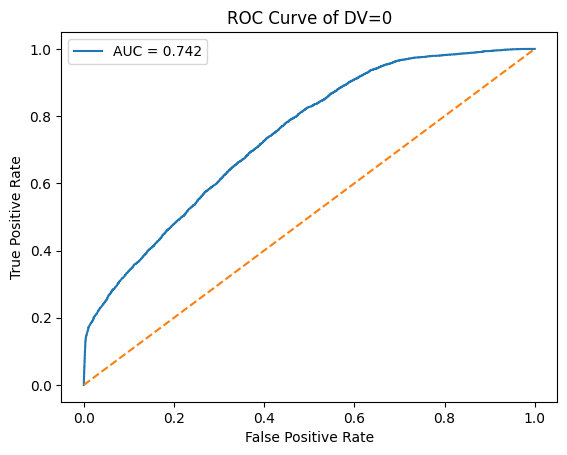

              precision    recall  f1-score   support

           0       0.77      0.16      0.27      4822
           1       0.86      0.99      0.92     25178

    accuracy                           0.86     30000
   macro avg       0.82      0.58      0.60     30000
weighted avg       0.85      0.86      0.82     30000

current model auc:0.741868
current model name:Best Random Search Model
None
F1 optimal threshold for class 0: 0.23232323232323235
Classification report with threshold
              precision    recall  f1-score   support

           0       0.29      0.57      0.38      4822
           1       0.90      0.74      0.81     25178

    accuracy                           0.71     30000
   macro avg       0.59      0.65      0.60     30000
weighted avg       0.80      0.71      0.74     30000

0.23232323232323235
Youden threshold for class 0: 0.17228400707244873
Classification report with threshold
              precision    recall  f1-score   support

           0     

In [53]:
print(model_summary(XGB_sampler_model_smoted, X_val_fe, y_val, "Best Random Search Model"))
print(f1_threshold(XGB_sampler_model_smoted,X_val_fe,y_val))
print(Youden_threshold(XGB_sampler_model_smoted,X_val_fe,y_val))

In [54]:
best_XGB_sampler_model = XGB_sampler_model_smoted.best_estimator_

In [55]:
joblib.dump(best_XGB_sampler_model, "best_XGB_sampler_model_smoted.pkl")

['best_XGB_sampler_model_smoted.pkl']

In [170]:
loaded_model = joblib.load("best_XGB_sampler_model.pkl")

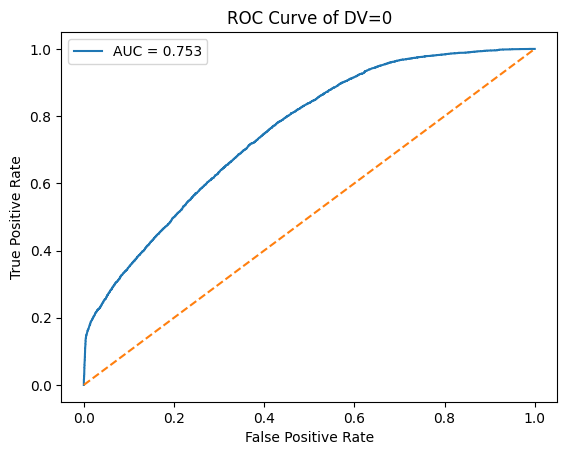

              precision    recall  f1-score   support

           0       0.33      0.47      0.39      4822
           1       0.89      0.82      0.85     25178

    accuracy                           0.76     30000
   macro avg       0.61      0.64      0.62     30000
weighted avg       0.80      0.76      0.78     30000

current model auc:0.752787
current model name:Best Random Search Model
None


In [171]:
print(model_summary(loaded_model, X_val_fe, y_val, "Best Random Search Model"))

In [172]:
XGB_param_no_sampler = [

    # XGBoost
    {
    "preprocess__num__drop_missing_cols__threshold": [50, 60, 70, 80, 90],
    "preprocess__cat__drop_missing_cols__threshold": [50, 60, 70, 80, 90],

    "sampler": ["passthrough"],

    "model": [
        XGBClassifier(
            random_state=42,
            eval_metric="logloss"
        )
    ],

    "model__n_estimators": [100, 300, 500, 800],
    "model__learning_rate": [0.01, 0.05, 0.1],
    "model__max_depth": [3, 4, 5],
    "model__subsample": [0.6, 0.8, 1.0],
    "model__colsample_bytree": [0.6, 0.8, 1.0],
    "model__booster": ["gbtree"],#"dart"

    "model__scale_pos_weight": [scale_pos_weight, 5, 10, 20],

    "model__reg_alpha": [0, 0.01, 0.1, 1],
    "model__reg_lambda": [1, 5, 10]
}
]

In [177]:
XGB_no_sampler_model = RandomizedSearchCV(
    estimator=pipe,
    param_distributions=XGB_param_no_sampler,
    n_iter=10,
    scoring=f1_class_0,
    cv=3,
    n_jobs=-1,
    random_state=42,
    verbose=2
)

XGB_no_sampler_model.fit(X_train_fe, y_train)

Fitting 3 folds for each of 10 candidates, totalling 30 fits


,estimator,Pipeline(step..._iter=1000))])
,param_distributions,"[{'model': [XGBClassifier...ree=None, ...)], 'model__booster': ['gbtree'], 'model__colsample_bytree': [0.6, 0.8, ...], 'model__learning_rate': [0.01, 0.05, ...], ...}]"
,n_iter,10
,scoring,"make_scorer(f..., pos_label=0)"
,n_jobs,-1
,refit,True
,cv,3
,verbose,2
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [178]:
joblib.dump(XGB_no_sampler_model, "XGB_no_sampler_model.pkl")

['XGB_no_sampler_model.pkl']

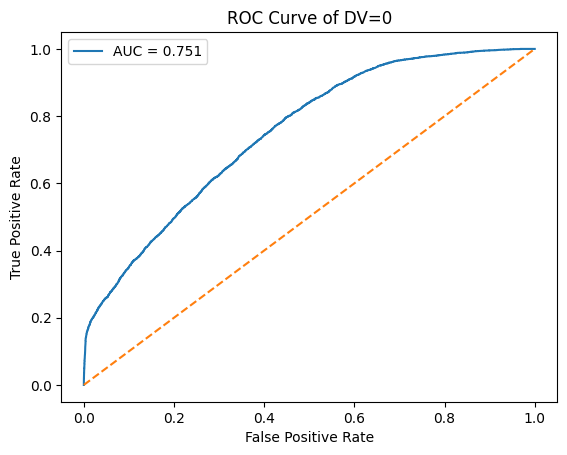

              precision    recall  f1-score   support

           0       0.92      0.04      0.08      4822
           1       0.85      1.00      0.92     25178

    accuracy                           0.85     30000
   macro avg       0.88      0.52      0.50     30000
weighted avg       0.86      0.85      0.78     30000

current model auc:0.750829
current model name:Best Random Search Model
None
F1 optimal threshold for class 0: 0.020202020202020204
Classification report with threshold
              precision    recall  f1-score   support

           0       0.27      0.68      0.39      4822
           1       0.91      0.66      0.76     25178

    accuracy                           0.66     30000
   macro avg       0.59      0.67      0.58     30000
weighted avg       0.81      0.66      0.70     30000

0.020202020202020204
Youden threshold for class 0: 0.017164766788482666
Classification report with threshold
              precision    recall  f1-score   support

           0  

In [179]:
print(model_summary(XGB_no_sampler_model, X_val_fe, y_val, "Best Random Search Model"))
print(f1_threshold(XGB_no_sampler_model,X_val_fe,y_val))
print(Youden_threshold(XGB_no_sampler_model,X_val_fe,y_val))

In [182]:
XGB_param_mixed = [

    # XGBoost
    {
    "preprocess__num__drop_missing_cols__threshold": [50, 60, 70, 80, 90],
    "preprocess__cat__drop_missing_cols__threshold": [50, 60, 70, 80, 90],

    "sampler": [
    # Undersampling
    RandomUnderSampler(sampling_strategy=0.30, random_state=42),
    RandomUnderSampler(sampling_strategy=0.40, random_state=42),
    RandomUnderSampler(sampling_strategy=0.50, random_state=42),
    RandomUnderSampler(sampling_strategy=0.70, random_state=42),

    # Oversampling
    RandomOverSampler(sampling_strategy=0.25, random_state=42),
    RandomOverSampler(sampling_strategy=0.35, random_state=42),
    RandomOverSampler(sampling_strategy=0.50, random_state=42),

    # SMOTE
    SMOTE(sampling_strategy=0.25, k_neighbors=3, random_state=42),
    SMOTE(sampling_strategy=0.35, k_neighbors=3, random_state=42),
    SMOTE(sampling_strategy=0.50, k_neighbors=3, random_state=42),

    SMOTE(sampling_strategy=0.25, k_neighbors=5, random_state=42),
    SMOTE(sampling_strategy=0.35, k_neighbors=5, random_state=42),
    SMOTE(sampling_strategy=0.50, k_neighbors=5, random_state=42),

    SMOTE(sampling_strategy=0.70, k_neighbors=5, random_state=42),
],

    "model": [
        XGBClassifier(
            random_state=42,
            eval_metric="logloss",
            objective="binary:logistic"
        )
    ],

    "model__n_estimators": [100, 300, 500, 800],
    "model__learning_rate": [0.01, 0.05, 0.1],
    "model__max_depth": [3, 4, 5],
    "model__subsample": [0.6, 0.8, 1.0],
    "model__colsample_bytree": [0.6, 0.8, 1.0],
    "model__booster": ["gbtree"],#"dart"

    "model__scale_pos_weight": [scale_pos_weight, 5, 10, 20],

    "model__reg_alpha": [0, 0.01, 0.1, 1],
    "model__reg_lambda": [1, 5, 10]
}
]

In [183]:
XGB_mixed_model = RandomizedSearchCV(
    estimator=pipe,
    param_distributions=XGB_param_mixed,
    n_iter=10,
    scoring=f1_class_0,
    cv=3,
    n_jobs=-1,
    random_state=42,
    verbose=2
)

XGB_mixed_model.fit(X_train_fe, y_train)

Fitting 3 folds for each of 10 candidates, totalling 30 fits


,estimator,Pipeline(step..._iter=1000))])
,param_distributions,"[{'model': [XGBClassifier...ree=None, ...)], 'model__booster': ['gbtree'], 'model__colsample_bytree': [0.6, 0.8, ...], 'model__learning_rate': [0.01, 0.05, ...], ...}]"
,n_iter,10
,scoring,"make_scorer(f..., pos_label=0)"
,n_jobs,-1
,refit,True
,cv,3
,verbose,2
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [184]:
joblib.dump(XGB_mixed_model, "XGB_mixed_model.pkl")

['XGB_mixed_model.pkl']

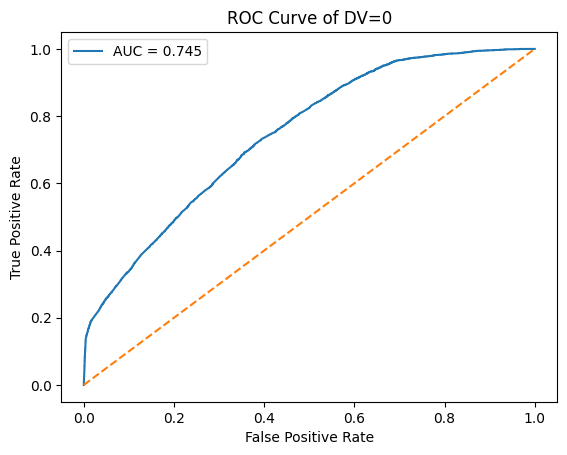

              precision    recall  f1-score   support

           0       0.21      0.96      0.35      4822
           1       0.98      0.32      0.48     25178

    accuracy                           0.42     30000
   macro avg       0.59      0.64      0.41     30000
weighted avg       0.85      0.42      0.46     30000

current model auc:0.745166
current model name:Best Random Search Model
None
F1 optimal threshold for class 0: 0.6565656565656566
Classification report with threshold
              precision    recall  f1-score   support

           0       0.27      0.68      0.39      4822
           1       0.91      0.65      0.76     25178

    accuracy                           0.66     30000
   macro avg       0.59      0.67      0.57     30000
weighted avg       0.81      0.66      0.70     30000

0.6565656565656566
Youden threshold for class 0: 0.6445636749267578
Classification report with threshold
              precision    recall  f1-score   support

           0       0

In [185]:
print(model_summary(XGB_mixed_model, X_val_fe, y_val, "Best Random Search Model"))
print(f1_threshold(XGB_mixed_model,X_val_fe,y_val))
print(Youden_threshold(XGB_mixed_model,X_val_fe,y_val))

In [187]:
param_dist_random_forest = [
    {
        "preprocess__num__drop_missing_cols__threshold": [50, 60, 70, 80, 90],
        "preprocess__cat__drop_missing_cols__threshold": [50, 60, 70, 80, 90],

        "sampler": [
            RandomUnderSampler(sampling_strategy=0.30, random_state=42),
            RandomUnderSampler(sampling_strategy=0.50, random_state=42),
            RandomUnderSampler(sampling_strategy=0.70, random_state=42),

            RandomOverSampler(sampling_strategy=0.35, random_state=42),
            RandomOverSampler(sampling_strategy=0.50, random_state=42),

            SMOTE(sampling_strategy=0.35, k_neighbors=5, random_state=42),
            SMOTE(sampling_strategy=0.50, k_neighbors=5, random_state=42),
            SMOTE(sampling_strategy=0.70, k_neighbors=5, random_state=42),
        ],

        "model": [RandomForestClassifier(random_state=42, n_jobs=-1)],

        "model__n_estimators": [300, 500, 800,1000],
        "model__max_depth": [None, 10, 20, 30],
        "model__min_samples_split": [2, 5, 10],
        "model__min_samples_leaf": [1, 2, 5, 10],
        "model__max_features": ["sqrt", "log2"],
        "model__criterion": ["gini", "entropy"],

        "model__class_weight": ["balanced", {0: 2, 1: 1},
    {0: 3, 1: 1},
    {0: 5, 1: 1}],

        "model__bootstrap": [True, False],
    }
]

In [189]:
rf_model = RandomizedSearchCV(
    estimator=pipe,
    param_distributions=param_dist_random_forest,
    n_iter=10,
    scoring=f1_class_0,
    cv=3,
    n_jobs=-1,
    random_state=42,
    verbose=2
)

rf_model.fit(X_train_fe, y_train)

Fitting 3 folds for each of 10 candidates, totalling 30 fits


,estimator,Pipeline(step..._iter=1000))])
,param_distributions,"[{'model': [RandomForestC...ndom_state=42)], 'model__bootstrap': [True, False], 'model__class_weight': ['balanced', {0: 2, 1: 1}, ...], 'model__criterion': ['gini', 'entropy'], ...}]"
,n_iter,10
,scoring,"make_scorer(f..., pos_label=0)"
,n_jobs,-1
,refit,True
,cv,3
,verbose,2
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [190]:
joblib.dump(rf_model, "rf_model.pkl")

['rf_model.pkl']

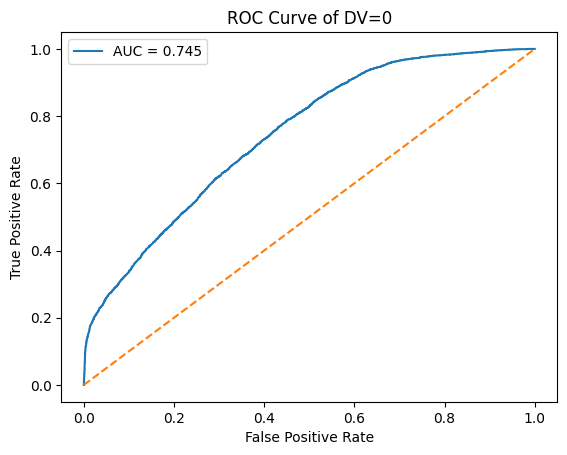

              precision    recall  f1-score   support

           0       0.28      0.62      0.39      4822
           1       0.91      0.70      0.79     25178

    accuracy                           0.69     30000
   macro avg       0.59      0.66      0.59     30000
weighted avg       0.81      0.69      0.73     30000

current model auc:0.745237
current model name:Best Random Search Model
None
F1 optimal threshold for class 0: 0.5050505050505051
Classification report with threshold
              precision    recall  f1-score   support

           0       0.29      0.61      0.39      4822
           1       0.90      0.71      0.80     25178

    accuracy                           0.69     30000
   macro avg       0.60      0.66      0.59     30000
weighted avg       0.81      0.69      0.73     30000

0.5050505050505051
Youden threshold for class 0: 0.43733279205670217
Classification report with threshold
              precision    recall  f1-score   support

           0       

In [191]:
print(model_summary(rf_model, X_val_fe, y_val, "Best Random Search Model"))
print(f1_threshold(rf_model,X_val_fe,y_val))
print(Youden_threshold(rf_model,X_val_fe,y_val))

In [192]:
from imblearn.ensemble import BalancedBaggingClassifier
from sklearn.tree import DecisionTreeClassifier

bbc = BalancedBaggingClassifier(
    estimator=DecisionTreeClassifier(random_state=42),
    n_estimators=100,
    sampling_strategy="auto",
    replacement=False,
    random_state=42,
    n_jobs=-1
)

In [194]:

param_bagging = [
    {
        "model": [
            BalancedBaggingClassifier(
                estimator=DecisionTreeClassifier(random_state=42),
                random_state=42,
                n_jobs=1
            )
        ],

        # Stronger imbalance handling
        "model__sampling_strategy": ["auto", 0.3, 0.5, 0.7, 1.0],
        "model__replacement": [True, False],

        # More trees = more stable
        "model__n_estimators": [100, 300, 500,800],

        # Control tree overfitting
        "model__estimator__max_depth": [3, 5, 10, 20, None],
        "model__estimator__min_samples_leaf": [1, 2, 5, 10, 20],
        "model__estimator__min_samples_split": [2, 5, 10, 20],

        # Extra imbalance pressure inside each tree
        "model__estimator__class_weight": ["balanced"],

        # Randomness / diversity
        "model__max_samples": [0.5, 0.75, 1.0],
        "model__max_features": [0.5, 0.75, 1.0]
    }
]

In [196]:
bagging_search = RandomizedSearchCV(
    estimator=pipe,
    param_distributions=param_bagging,
    n_iter=5,
    scoring=f1_class_0,
    cv=3,
    n_jobs=1,
    random_state=42,
    verbose=0
)

bagging_search.fit(X_train_fe, y_train)

,estimator,Pipeline(step..._iter=1000))])
,param_distributions,"[{'model': [BalancedBaggi...ndom_state=42)], 'model__estimator__class_weight': ['balanced'], 'model__estimator__max_depth': [3, 5, ...], 'model__estimator__min_samples_leaf': [1, 2, ...], ...}]"
,n_iter,5
,scoring,"make_scorer(f..., pos_label=0)"
,n_jobs,1
,refit,True
,cv,3
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [197]:
joblib.dump(bagging_search, "bagging_search_model.pkl")

['bagging_search_model.pkl']

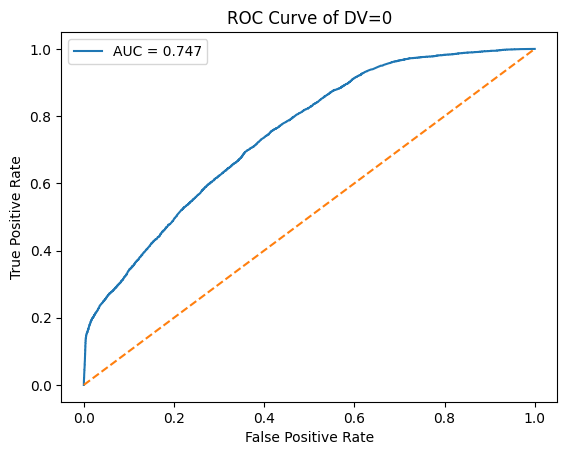

              precision    recall  f1-score   support

           0       0.26      0.76      0.38      4822
           1       0.93      0.58      0.71     25178

    accuracy                           0.61     30000
   macro avg       0.59      0.67      0.55     30000
weighted avg       0.82      0.61      0.66     30000

current model auc:0.746726
current model name:Best Random Search Model
None
F1 optimal threshold for class 0: 0.5555555555555556
Classification report with threshold
              precision    recall  f1-score   support

           0       0.30      0.58      0.39      4822
           1       0.90      0.74      0.81     25178

    accuracy                           0.71     30000
   macro avg       0.60      0.66      0.60     30000
weighted avg       0.80      0.71      0.74     30000

0.5555555555555556
Youden threshold for class 0: 0.5028879772402
Classification report with threshold
              precision    recall  f1-score   support

           0       0.26

In [198]:
print(model_summary(bagging_search, X_val_fe, y_val, "Best Random Search Model"))
print(f1_threshold(bagging_search,X_val_fe,y_val))
print(Youden_threshold(bagging_search,X_val_fe,y_val))

## Pipeline name extraction

In [200]:
lr_l2_sampler_param = [
    {
        "preprocess__num__drop_missing_cols__threshold": [50, 60, 70, 80, 90],
        "preprocess__cat__drop_missing_cols__threshold": [50, 60, 70, 80, 90],

        "sampler": [
            # No sampler baseline inside sampler search
            "passthrough",

            # Undersampling majority class
            RandomUnderSampler(sampling_strategy=0.30, random_state=42),
            RandomUnderSampler(sampling_strategy=0.50, random_state=42),
            RandomUnderSampler(sampling_strategy=0.70, random_state=42),

            # Oversampling minority class 0
            RandomOverSampler(sampling_strategy=0.30, random_state=42),
            RandomOverSampler(sampling_strategy=0.50, random_state=42),
            RandomOverSampler(sampling_strategy=0.70, random_state=42),

            # SMOTE versions
            SMOTE(sampling_strategy=0.30, k_neighbors=3, random_state=42),
            SMOTE(sampling_strategy=0.50, k_neighbors=3, random_state=42),
            SMOTE(sampling_strategy=0.70, k_neighbors=3, random_state=42),

            SMOTE(sampling_strategy=0.30, k_neighbors=5, random_state=42),
            SMOTE(sampling_strategy=0.50, k_neighbors=5, random_state=42),
            SMOTE(sampling_strategy=0.70, k_neighbors=5, random_state=42),
        ],

        "model": [
            LogisticRegression(
                max_iter=5000,
                fit_intercept=True,
                random_state=42
            )
        ],

        "model__penalty": ["l2"],
        "model__C": [0.001, 0.01, 0.1, 1, 10, 100],
        "model__solver": ["lbfgs", "saga"],
        "model__class_weight": [None],
        "model__tol": [1e-4, 1e-3]
    }
]

In [201]:
lr_l2_sampler_model = RandomizedSearchCV(
    estimator=pipe,
    param_distributions=lr_l2_sampler_param,
    n_iter=10,
    scoring=f1_class_0,
    cv=3,
    n_jobs=-1,
    random_state=42,
    verbose=0
)

lr_l2_sampler_model.fit(X_train_fe, y_train)

,estimator,Pipeline(step..._iter=1000))])
,param_distributions,"[{'model': [LogisticRegre...ndom_state=42)], 'model__C': [0.001, 0.01, ...], 'model__class_weight': [None], 'model__penalty': ['l2'], ...}]"
,n_iter,10
,scoring,"make_scorer(f..., pos_label=0)"
,n_jobs,-1
,refit,True
,cv,3
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [202]:
joblib.dump(lr_l2_sampler_model, "lr_l2_sampler_model.pkl")

['lr_l2_sampler_model.pkl']

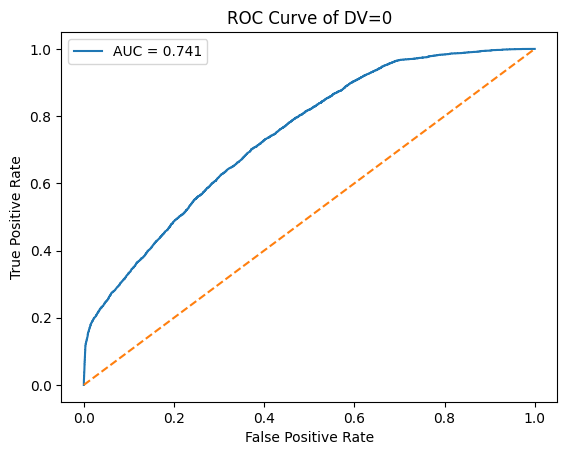

              precision    recall  f1-score   support

           0       0.47      0.26      0.34      4822
           1       0.87      0.94      0.90     25178

    accuracy                           0.83     30000
   macro avg       0.67      0.60      0.62     30000
weighted avg       0.81      0.83      0.81     30000

current model auc:0.741500
current model name:Best Random Search Model
None
F1 optimal threshold for class 0: 0.393939393939394
Classification report with threshold
              precision    recall  f1-score   support

           0       0.30      0.55      0.39      4822
           1       0.90      0.76      0.82     25178

    accuracy                           0.72     30000
   macro avg       0.60      0.65      0.60     30000
weighted avg       0.80      0.72      0.75     30000

0.393939393939394
Youden threshold for class 0: 0.3479621836953173
Classification report with threshold
              precision    recall  f1-score   support

           0       0.2

In [203]:
print(model_summary(lr_l2_sampler_model, X_val_fe, y_val, "Best Random Search Model"))
print(f1_threshold(lr_l2_sampler_model,X_val_fe,y_val))
print(Youden_threshold(lr_l2_sampler_model,X_val_fe,y_val))

In [205]:
lr_l1_sampler_param = [
    {
        "preprocess__num__drop_missing_cols__threshold": [50, 60, 70, 80, 90],
        "preprocess__cat__drop_missing_cols__threshold": [50, 60, 70, 80, 90],

        "sampler": [
            "passthrough",

            # Undersampling majority class
            RandomUnderSampler(sampling_strategy=0.30, random_state=42),
            RandomUnderSampler(sampling_strategy=0.50, random_state=42),
            RandomUnderSampler(sampling_strategy=0.70, random_state=42),

            # Oversampling minority class 0
            RandomOverSampler(sampling_strategy=0.30, random_state=42),
            RandomOverSampler(sampling_strategy=0.50, random_state=42),
            RandomOverSampler(sampling_strategy=0.70, random_state=42),

            # SMOTE versions
            SMOTE(sampling_strategy=0.30, k_neighbors=3, random_state=42),
            SMOTE(sampling_strategy=0.50, k_neighbors=3, random_state=42),
            SMOTE(sampling_strategy=0.70, k_neighbors=3, random_state=42),

            SMOTE(sampling_strategy=0.30, k_neighbors=5, random_state=42),
            SMOTE(sampling_strategy=0.50, k_neighbors=5, random_state=42),
            SMOTE(sampling_strategy=0.70, k_neighbors=5, random_state=42),
        ],

        "model": [
            LogisticRegression(
                max_iter=5000,
                fit_intercept=True,
                random_state=42
            )
        ],

        "model__penalty": ["l1"],
        "model__C": [0.001, 0.01, 0.1, 1, 10],
        "model__solver": ["saga"],
        "model__class_weight": [None],
        "model__tol": [1e-4, 1e-3]
    }
]

In [206]:
lr_l1_sampler_model = RandomizedSearchCV(
    estimator=pipe,
    param_distributions=lr_l1_sampler_param,
    n_iter=10,
    scoring=f1_class_0,
    cv=3,
    n_jobs=1,
    random_state=42,
    verbose=0
)

lr_l1_sampler_model.fit(X_train_fe, y_train)

,estimator,Pipeline(step..._iter=1000))])
,param_distributions,"[{'model': [LogisticRegre...ndom_state=42)], 'model__C': [0.001, 0.01, ...], 'model__class_weight': [None], 'model__penalty': ['l1'], ...}]"
,n_iter,10
,scoring,"make_scorer(f..., pos_label=0)"
,n_jobs,1
,refit,True
,cv,3
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [207]:
joblib.dump(lr_l1_sampler_model, "lr_l1_sampler_model.pkl")

['lr_l1_sampler_model.pkl']

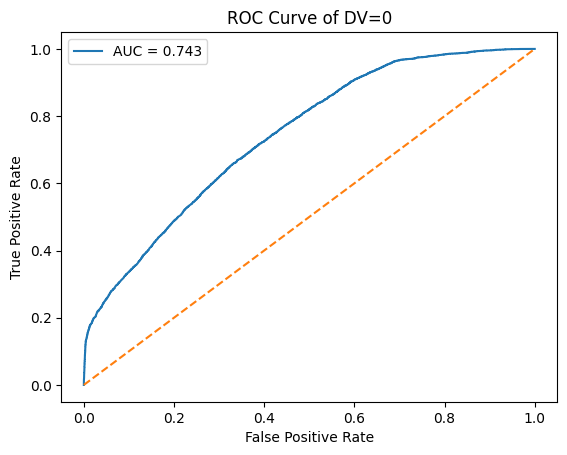

              precision    recall  f1-score   support

           0       0.32      0.48      0.38      4822
           1       0.89      0.80      0.85     25178

    accuracy                           0.75     30000
   macro avg       0.61      0.64      0.62     30000
weighted avg       0.80      0.75      0.77     30000

current model auc:0.742851
current model name:Best Random Search Model
None
F1 optimal threshold for class 0: 0.4747474747474748
Classification report with threshold
              precision    recall  f1-score   support

           0       0.30      0.57      0.39      4822
           1       0.90      0.74      0.81     25178

    accuracy                           0.71     30000
   macro avg       0.60      0.65      0.60     30000
weighted avg       0.80      0.71      0.74     30000

0.4747474747474748
Youden threshold for class 0: 0.4449829114864826
Classification report with threshold
              precision    recall  f1-score   support

           0       0

In [208]:
print(model_summary(lr_l1_sampler_model, X_val_fe, y_val, "Best Random Search Model"))
print(f1_threshold(lr_l1_sampler_model,X_val_fe,y_val))
print(Youden_threshold(lr_l1_sampler_model,X_val_fe,y_val))

In [211]:
lr_l2_weights_param = [
    {
        "preprocess__num__drop_missing_cols__threshold": [50, 60, 70, 80, 90],
        "preprocess__cat__drop_missing_cols__threshold": [50, 60, 70, 80, 90],

        "sampler": ["passthrough"],

        "model": [
            LogisticRegression(
                max_iter=5000,
                fit_intercept=True,
                random_state=42
            )
        ],

        "model__penalty": ["l2"],
        "model__C": [0.001, 0.01, 0.1, 1, 10, 100],

        # lbfgs is usually faster; saga is okay to compare
        "model__solver": ["lbfgs", "saga"],

        # class 0 is your minority, so these weights focus more on class 0
        "model__class_weight": [
            None,
            "balanced",
            {0: 2, 1: 1},
            {0: 3, 1: 1},
            {0: 5, 1: 1},
            {0: 10, 1: 1}
        ],

        "model__tol": [1e-4, 1e-3]
    }
]

In [212]:
lr_l2_weights_model = RandomizedSearchCV(
    estimator=pipe,
    param_distributions=lr_l2_weights_param,
    n_iter=10,
    scoring=f1_class_0,
    cv=3,
    n_jobs=1,
    random_state=42,
    verbose=0
)

lr_l2_weights_model.fit(X_train_fe, y_train)

,estimator,Pipeline(step..._iter=1000))])
,param_distributions,"[{'model': [LogisticRegre...ndom_state=42)], 'model__C': [0.001, 0.01, ...], 'model__class_weight': [None, 'balanced', ...], 'model__penalty': ['l2'], ...}]"
,n_iter,10
,scoring,"make_scorer(f..., pos_label=0)"
,n_jobs,1
,refit,True
,cv,3
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [213]:
joblib.dump(lr_l2_weights_model, "lr_l2_weights_model.pkl")

['lr_l2_weights_model.pkl']

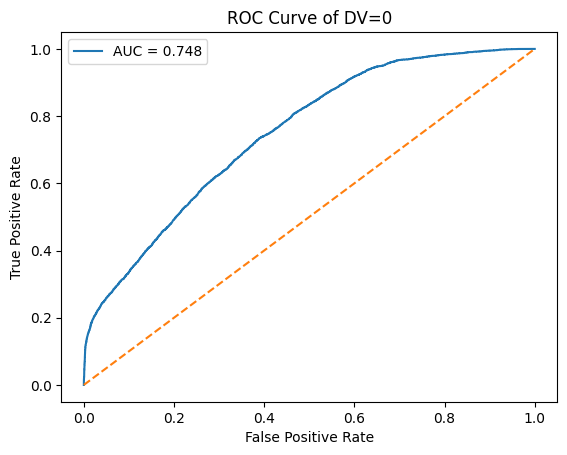

              precision    recall  f1-score   support

           0       0.27      0.72      0.39      4822
           1       0.92      0.62      0.74     25178

    accuracy                           0.64     30000
   macro avg       0.59      0.67      0.57     30000
weighted avg       0.82      0.64      0.69     30000

current model auc:0.748405
current model name:Best Random Search Model
None
F1 optimal threshold for class 0: 0.5353535353535354
Classification report with threshold
              precision    recall  f1-score   support

           0       0.29      0.60      0.40      4822
           1       0.90      0.72      0.80     25178

    accuracy                           0.70     30000
   macro avg       0.60      0.66      0.60     30000
weighted avg       0.81      0.70      0.74     30000

0.5353535353535354
Youden threshold for class 0: 0.4953861270581327
Classification report with threshold
              precision    recall  f1-score   support

           0       0

In [214]:
print(model_summary(lr_l2_weights_model, X_val_fe, y_val, "Best Random Search Model"))
print(f1_threshold(lr_l2_weights_model,X_val_fe,y_val))
print(Youden_threshold(lr_l2_weights_model,X_val_fe,y_val))

In [225]:
lr_l1_weights_param = [
    # --------------------------------------------------
    # 4. Logistic Regression - L1 with no sampler + class weights
    # --------------------------------------------------
    {
        "preprocess__num__drop_missing_cols__threshold": [50, 60, 70, 80, 90],
        "preprocess__cat__drop_missing_cols__threshold": [50, 60, 70, 80, 90],

        "sampler": ["passthrough"],

        "model": [
            LogisticRegression(
                max_iter=5000,
                fit_intercept=True,
                random_state=42
            )
        ],

        "model__penalty": ["l1"],
        "model__C": [0.001, 0.01, 0.1, 1, 10],
        "model__solver": ["saga"],

        "model__class_weight": [
            None,
            "balanced",
            {0: 2, 1: 1},
            {0: 3, 1: 1},
            {0: 5, 1: 1},
            {0: 10, 1: 1}
        ],

        "model__tol": [1e-4, 1e-3]
    }
]

In [227]:
lr_l1_weights_model = RandomizedSearchCV(
    estimator=pipe,
    param_distributions=lr_l1_weights_param,
    n_iter=10,
    scoring=f1_class_0,
    cv=3,
    n_jobs=1,
    random_state=42,
    verbose=0
)

lr_l1_weights_model.fit(X_train_fe, y_train)

,estimator,Pipeline(step..._iter=1000))])
,param_distributions,"[{'model': [LogisticRegre...ndom_state=42)], 'model__C': [0.001, 0.01, ...], 'model__class_weight': [None, 'balanced', ...], 'model__penalty': ['l1'], ...}]"
,n_iter,10
,scoring,"make_scorer(f..., pos_label=0)"
,n_jobs,1
,refit,True
,cv,3
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [228]:
joblib.dump(lr_l1_weights_model, "lr_l1_weights_model.pkl")

['lr_l1_weights_model.pkl']

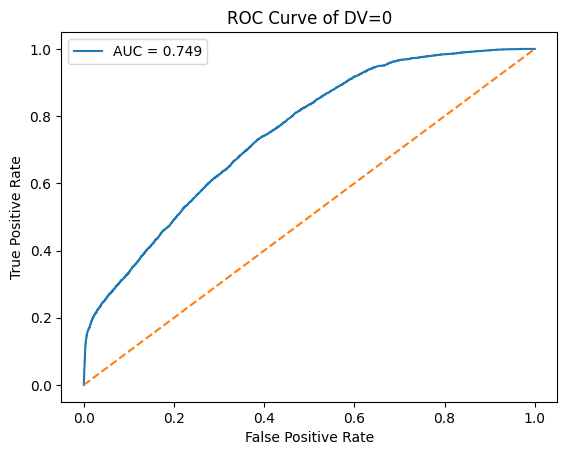

              precision    recall  f1-score   support

           0       0.27      0.72      0.39      4822
           1       0.92      0.63      0.75     25178

    accuracy                           0.64     30000
   macro avg       0.59      0.67      0.57     30000
weighted avg       0.82      0.64      0.69     30000

current model auc:0.748654
current model name:Best Random Search Model
None
F1 optimal threshold for class 0: 0.5353535353535354
Classification report with threshold
              precision    recall  f1-score   support

           0       0.29      0.60      0.39      4822
           1       0.90      0.72      0.80     25178

    accuracy                           0.70     30000
   macro avg       0.60      0.66      0.60     30000
weighted avg       0.81      0.70      0.74     30000

0.5353535353535354
Youden threshold for class 0: 0.49593943162193943
Classification report with threshold
              precision    recall  f1-score   support

           0       

In [229]:
print(model_summary(lr_l1_weights_model, X_val_fe, y_val, "Best Random Search Model"))
print(f1_threshold(lr_l1_weights_model,X_val_fe,y_val))
print(Youden_threshold(lr_l1_weights_model,X_val_fe,y_val))

In [122]:
from torch.optim import Adam
from skorch import NeuralNetClassifier

In [123]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cpu'

In [124]:
from skorch.callbacks import EarlyStopping

In [125]:
class MLPClassifier_largeNN(nn.Module):
    def __init__(self, dropout=0.30):
        super().__init__()
#Start with a dense layer to capture information and then decrease to local features
        self.network = nn.Sequential(
            nn.LazyLinear(256),


            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(p=dropout),

            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(p=dropout),

            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(p=dropout),

            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Dropout(p=dropout),

            nn.Linear(16, 2)
        )

    def forward(self, X):
        logits = self.network(X)
        return logits

In [126]:
class_weights = torch.tensor([3.0, 1.0], dtype=torch.float32).to(device)

In [127]:
net = NeuralNetClassifier(
    module=MLPClassifier_largeNN,
    module__dropout=0.3,
    

    criterion=nn.CrossEntropyLoss,
    criterion__weight=class_weights,

    optimizer=torch.optim.Adam,
    optimizer__lr=0.001,
    optimizer__weight_decay=0.001,

    max_epochs=100,
    batch_size=256,
    iterator_train__shuffle=True,
    device=device,
    verbose=1,
    callbacks=[
        EarlyStopping(
            monitor="valid_loss",
            patience=10,
            threshold=0.0001,
            threshold_mode="rel",
            lower_is_better=True
        )
    ]
)

In [128]:
from sklearn.preprocessing import FunctionTransformer

In [129]:
nn_pipe = Pipeline(steps=[
    ("preprocess", preprocessing),
    ("to_float32", FunctionTransformer(lambda X: X.astype(np.float32), validate=False)),
    ("model", net)
])

In [63]:
nn_pipe.fit(X_train_fe, y_train)

  epoch    train_loss    valid_acc    valid_loss     dur
-------  ------------  -----------  ------------  ------
      1        0.5552       0.7566        0.5191  5.0846
      2        0.5274       0.7577        0.5154  4.8683
      3        0.5259       0.7908        0.5123  3.6681
      4        0.5247       0.8042        0.5141  5.2797
      5        0.5243       0.8444        0.5183  8.8200
      6        0.5238       0.8044        0.5116  11.4445
      7        0.5221       0.8047        0.5155  13.2514
      8        0.5215       0.8213        0.5135  14.2532
      9        0.5211       0.8295        0.5121  14.6814
     10        0.5216       0.8134        0.5096  14.9265
     11        0.5210       0.8034        0.5087  15.1010
     12        0.5209       0.8017        0.5089  15.2454
     13        0.5220       0.8075        0.5088  15.8580
     14        0.5191       0.8334        0.5130  15.5044
     15        0.5199       0.8157        0.5110  15.2507
     16        0.5206

,steps,"[('preprocess', ...), ('to_float32', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for forma

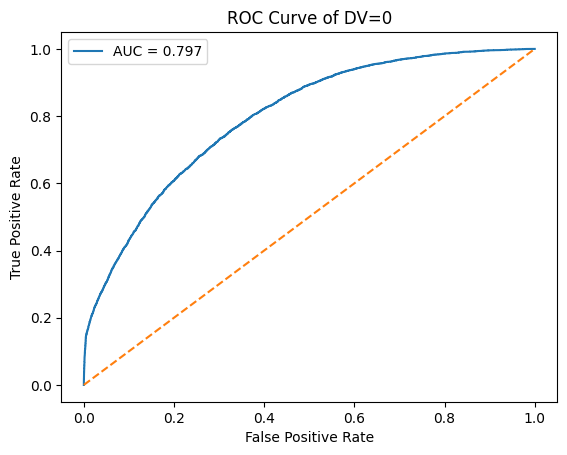

              precision    recall  f1-score   support

           0       0.43      0.49      0.45      4822
           1       0.90      0.87      0.89     25178

    accuracy                           0.81     30000
   macro avg       0.66      0.68      0.67     30000
weighted avg       0.82      0.81      0.82     30000

current model auc:0.797182
current model name:a


In [64]:
model_summary(nn_pipe, X_val_fe, y_val, "a")

In [65]:
f1_threshold(nn_pipe,X_val_fe, y_val)

F1 optimal threshold for class 0: 0.4747474747474748
Classification report with threshold
              precision    recall  f1-score   support

           0       0.39      0.57      0.46      4822
           1       0.91      0.83      0.87     25178

    accuracy                           0.79     30000
   macro avg       0.65      0.70      0.66     30000
weighted avg       0.83      0.79      0.80     30000



np.float64(0.4747474747474748)

In [130]:
from scipy.stats import loguniform, uniform

In [131]:
param_dist_nn = {
    # learning rate
    "model__optimizer__lr": loguniform(1e-4, 1e-2),

    # regularization
    "model__optimizer__weight_decay": loguniform(1e-5, 1e-1),

    # dropout: tries values from 0.10 to 0.50
    "model__module__dropout": uniform(0.1, 0.4),

    # batch size
    "model__batch_size": [128, 256, 512],

    # optimizer
    "model__optimizer": [
        torch.optim.Adam,
        torch.optim.AdamW
    ],

    # class imbalance weights
    # order is [class_0_weight, class_1_weight]
    "model__criterion__weight": [
        torch.tensor([1.0, 1.0], dtype=torch.float32).to(device),
        torch.tensor([2.0, 1.0], dtype=torch.float32).to(device),
        torch.tensor([3.0, 1.0], dtype=torch.float32).to(device),
        torch.tensor([5.0, 1.0], dtype=torch.float32).to(device),
        torch.tensor([10.0, 1.0], dtype=torch.float32).to(device),
    ]
}

In [ ]:




random_search_Lnn = RandomizedSearchCV(
    estimator=nn_pipe,
    param_distributions=param_dist_nn,
    n_iter=15,
    scoring=f1_class_0,
    cv=3,
    random_state=42,
    verbose=2,
    n_jobs=1
)

random_search_Lnn.fit(X_train_fe, y_train.astype("int64"))

Fitting 3 folds for each of 15 candidates, totalling 45 fits
  epoch    train_loss    valid_acc    valid_loss     dur
-------  ------------  -----------  ------------  ------
      1        0.6229       0.6634        0.5716  2.2336
      2        0.5856       0.6616        0.5619  2.2673
      3        0.5796       0.6857        0.5545  2.3722
      4        0.5780       0.7088        0.5522  2.2647
      5        0.5731       0.6737        0.5534  2.2377
      6        0.5723       0.6413        0.5602  2.2625
      7        0.5737       0.6798        0.5566  2.2019
      8        0.5718       0.6353        0.5609  2.1162
      9        0.5743       0.7000        0.5550  2.2990
     10        0.5751       0.7196        0.5512  2.9872
     11        0.5748       0.6377        0.5519  2.4371
     12        0.5731       0.6853        0.5522  5.1340
     13        0.5705       0.6970        0.5537  6.5037
     14        0.5717       0.7021        0.5514  7.6247
     15        0.5727      

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...tart=False))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'model__batch_size': [128, 256, ...], 'model__criterion__weight': [tensor([1., 1.]), tensor([2., 1.]), ...], 'model__module__dropout': <scipy.stats....00283A94A82D0>, 'model__optimizer': [<class 'torch...im.adam.Adam'>, <class 'torch....adamw.AdamW'>], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",15
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.","make_scorer(f..., pos_label=0)"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `

In [67]:
class MLPClassifier_smallNN(nn.Module):
    def __init__(self, dropout=0.30):
        super().__init__()

        self.network = nn.Sequential(
            nn.LazyLinear(64),
            nn.ReLU(),
            nn.Dropout(p=dropout),

            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(p=dropout),

            nn.Linear(32, 2)
        )

    def forward(self, X):
        logits = self.network(X)
        return logits

In [60]:
class MLPClassifier_mediumNN(nn.Module):
    def __init__(self, dropout=0.30):
        super().__init__()

        self.network = nn.Sequential(
            nn.LazyLinear(128),
            nn.ReLU(),
            nn.Dropout(p=dropout),

            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(p=dropout),

            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(p=dropout),

            nn.Linear(32, 2)
        )

    def forward(self, X):
        logits = self.network(X)
        return logits

In [61]:
net_med = NeuralNetClassifier(
    module=MLPClassifier_mediumNN,
    module__dropout=0.3,
    

    criterion=nn.CrossEntropyLoss,
    criterion__weight=class_weights,

    optimizer=torch.optim.Adam,
    optimizer__lr=0.001,
    optimizer__weight_decay=0.001,

    max_epochs=50,
    batch_size=256,
    iterator_train__shuffle=True,
    device=device,
    verbose=1,
    callbacks=[
        EarlyStopping(
            monitor="valid_loss",
            patience=10,
            threshold=0.0001,
            threshold_mode="rel",
            lower_is_better=True
        )
    ]
)

In [68]:
net_smol = NeuralNetClassifier(
    module=MLPClassifier_smallNN,
    module__dropout=0.3,
    

    criterion=nn.CrossEntropyLoss,
    criterion__weight=class_weights,

    optimizer=torch.optim.Adam,
    optimizer__lr=0.001,
    optimizer__weight_decay=0.001,

    max_epochs=50,
    batch_size=256,
    iterator_train__shuffle=True,
    device=device,
    verbose=1,
    callbacks=[
        EarlyStopping(
            monitor="valid_loss",
            patience=10,
            threshold=0.0001,
            threshold_mode="rel",
            lower_is_better=True
        )
    ]
)

In [62]:
nn_pipe_med = Pipeline(steps=[
    ("preprocess", preprocessing),
    ("to_float32", FunctionTransformer(lambda X: X.astype(np.float32), validate=False)),
    ("model", net_med)
])

In [69]:
nn_pipe_smol = Pipeline(steps=[
    ("preprocess", preprocessing),
    ("to_float32", FunctionTransformer(lambda X: X.astype(np.float32), validate=False)),
    ("model", net_smol)
])

In [63]:
random_search_Mnn = RandomizedSearchCV(
    estimator=nn_pipe_med,
    param_distributions=param_dist_nn,
    n_iter=10,
    scoring=f1_class_0,
    cv=3,
    random_state=42,
    verbose=2,
    n_jobs=1
)

random_search_Mnn.fit(X_train_fe, y_train.astype("int64"))

Fitting 3 folds for each of 10 candidates, totalling 30 fits
  epoch    train_loss    valid_acc    valid_loss     dur
-------  ------------  -----------  ------------  ------
      1        0.5898       0.6346        0.5531  1.9087
      2        0.5649       0.6665        0.5515  1.8165
      3        0.5630       0.7102        0.5503  2.0447
      4        0.5630       0.7310        0.5475  1.9648
      5        0.5624       0.7422        0.5533  2.4333
      6        0.5615       0.5940        0.5556  1.8898
      7        0.5622       0.6574        0.5486  1.8885
      8        0.5614       0.6632        0.5487  1.9561
      9        0.5625       0.6938        0.5490  1.9353
     10        0.5597       0.7287        0.5510  1.9607
     11        0.5607       0.6726        0.5475  1.8555
     12        0.5609       0.7191        0.5478  2.0596
     13        0.5594       0.7011        0.5493  1.8815
Stopping since valid_loss has not improved in the last 10 epochs.
[CV] END model__ba

,estimator,Pipeline(step...tart=False))])
,param_distributions,"{'model__batch_size': [128, 256, ...], 'model__criterion__weight': [tensor([1., 1.]), tensor([2., 1.]), ...], 'model__module__dropout': <scipy.stats....00180A10B0050>, 'model__optimizer': [<class 'torch...im.adam.Adam'>, <class 'torch....adamw.AdamW'>], ...}"
,n_iter,10
,scoring,"make_scorer(f..., pos_label=0)"
,n_jobs,1
,refit,True
,cv,3
,verbose,2
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [70]:
random_search_smol = RandomizedSearchCV(
    estimator=nn_pipe_smol,
    param_distributions=param_dist_nn,
    n_iter=15,
    scoring=f1_class_0,
    cv=3,
    random_state=42,
    verbose=2,
    n_jobs=1
)

random_search_smol.fit(X_train_fe, y_train.astype("int64"))

Fitting 3 folds for each of 15 candidates, totalling 45 fits
  epoch    train_loss    valid_acc    valid_loss     dur
-------  ------------  -----------  ------------  ------
      1        0.5942       0.6927        0.5488  1.5124
      2        0.5614       0.7003        0.5487  1.5093
      3        0.5601       0.6726        0.5473  1.6630
      4        0.5602       0.7061        0.5495  1.5597
      5        0.5593       0.6301        0.5511  1.6549
      6        0.5593       0.6563        0.5489  1.6776
      7        0.5593       0.7147        0.5519  1.5430
      8        0.5578       0.6607        0.5508  2.0177
      9        0.5599       0.7128        0.5519  2.0073
     10        0.5595       0.7045        0.5474  1.5456
     11        0.5584       0.6465        0.5488  1.7619
     12        0.5560       0.6896        0.5458  1.6193
     13        0.5578       0.6648        0.5458  1.5848
     14        0.5569       0.6756        0.5471  1.6009
     15        0.5570      

,estimator,Pipeline(step...tart=False))])
,param_distributions,"{'model__batch_size': [128, 256, ...], 'model__criterion__weight': [tensor([1., 1.]), tensor([2., 1.]), ...], 'model__module__dropout': <scipy.stats....00180A10B0050>, 'model__optimizer': [<class 'torch...im.adam.Adam'>, <class 'torch....adamw.AdamW'>], ...}"
,n_iter,15
,scoring,"make_scorer(f..., pos_label=0)"
,n_jobs,1
,refit,True
,cv,3
,verbose,2
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [73]:
# Best hyperparameters found by RandomizedSearchCV
random_search_Lnn.best_params_

{'model__batch_size': 256,
 'model__criterion__weight': tensor([3., 1.]),
 'model__module__dropout': np.float64(0.2529847965068651),
 'model__optimizer': torch.optim.adamw.AdamW,
 'model__optimizer__lr': np.float64(0.0015304852121831463),
 'model__optimizer__weight_decay': np.float64(1.5339162591163613e-05)}

In [65]:
random_search_Mnn.best_params_

{'model__batch_size': 512,
 'model__criterion__weight': tensor([5., 1.]),
 'model__module__dropout': np.float64(0.29807076404450805),
 'model__optimizer': torch.optim.adam.Adam,
 'model__optimizer__lr': np.float64(0.00022219245475399164),
 'model__optimizer__weight_decay': np.float64(0.0003666421832063722)}

In [71]:

random_search_smol.best_params_

{'model__batch_size': 256,
 'model__criterion__weight': tensor([5., 1.]),
 'model__module__dropout': np.float64(0.2246844304357644),
 'model__optimizer': torch.optim.adamw.AdamW,
 'model__optimizer__lr': np.float64(0.00026054534945804014),
 'model__optimizer__weight_decay': np.float64(0.0018655260217376823)}

# Best params for large NN:
'model__batch_size': 256,
 'model__criterion__weight': tensor([3., 1.]),
 'model__module__dropout': np.float64(0.2529847965068651),
 'model__optimizer': torch.optim.adamw.AdamW,
 'model__optimizer__lr': np.float64(0.0015304852121831463),
 'model__optimizer__weight_decay': np.float64(1.5339162591163613e-05)}


 ## Best params for medium NN:
 {'model__batch_size': 512,
 'model__criterion__weight': tensor([5., 1.]),
 'model__module__dropout': np.float64(0.29807076404450805),
 'model__optimizer': torch.optim.adam.Adam,
 'model__optimizer__lr': np.float64(0.00022219245475399164),
 'model__optimizer__weight_decay': np.float64(0.0003666421832063722)}


 ## Best params for small NN:
 {'model__batch_size': 256,
 'model__criterion__weight': tensor([5., 1.]),
 'model__module__dropout': np.float64(0.2246844304357644),
 'model__optimizer': torch.optim.adamw.AdamW,
 'model__optimizer__lr': np.float64(0.00026054534945804014),
 'model__optimizer__weight_decay': np.float64(0.0018655260217376823)}

In [70]:
best_model = random_search_Lnn.best_estimator_

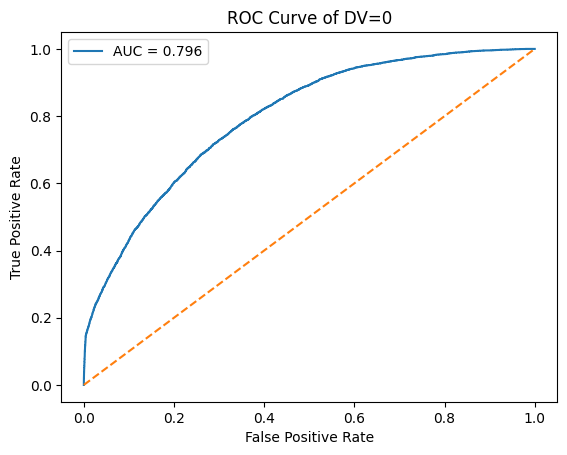

              precision    recall  f1-score   support

           0       0.32      0.73      0.44      4822
           1       0.93      0.70      0.80     25178

    accuracy                           0.71     30000
   macro avg       0.62      0.71      0.62     30000
weighted avg       0.83      0.71      0.74     30000

current model auc:0.796471
current model name:Best Random Search Model


In [72]:
model_summary(random_search_smol, X_val_fe, y_val, "Best Random Search Model")

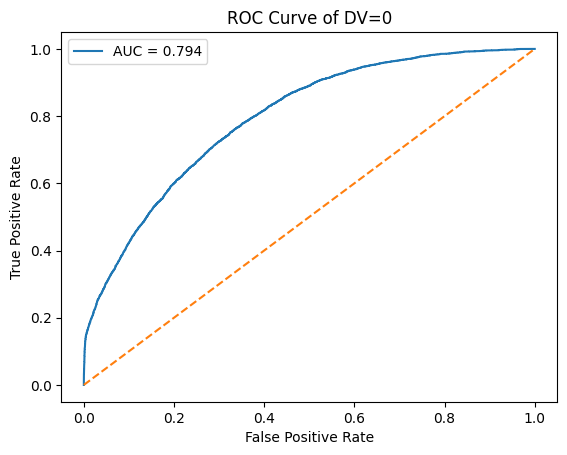

              precision    recall  f1-score   support

           0       0.39      0.54      0.45      4822
           1       0.90      0.84      0.87     25178

    accuracy                           0.79     30000
   macro avg       0.65      0.69      0.66     30000
weighted avg       0.82      0.79      0.80     30000

current model auc:0.794141
current model name:Best Random Search Model


In [68]:
model_summary(best_model, X_val_fe, y_val, "Best Random Search Model")

“Given the borrower and loan information available now, can we classify whether the loan is currently in good standing or risky?”

## ------------------------

In [ ]:
#Finds all the files in the current cworking directory that end with '.pkl'
model_files = glob.glob("*.pkl")

print("Found models:")
for file in model_files:
    print(file)

#Dictiorary initializer
models = {}

for file in model_files:
    try:
        model = joblib.load(file)
        models[file] = model
        print("\n" + "="*80)
        print(f"MODEL FILE: {file}")
        print("="*80)
        print(model)
        
        # If it is GridSearchCV or RandomizedSearchCV attributes
        if hasattr(model, "best_params_"):#Checks if the object hast attribute called best_params
            print("\nBest Parameters:")
            print(model.best_params_)
            
        if hasattr(model, "best_score_"):
            print("\nBest CV Score:")
            print(model.best_score_)
            
        if hasattr(model, "best_estimator_"):
            print("\nBest Estimator:")
            print(model.best_estimator_)
            
    except Exception as e:
        #Catches an exception and stroes the error in  the variable e
        print(f"Could not load {file}: {e}")

Found models:
bagging_search_model.pkl
best_largenn.pkl
best_XGB_sampler_model.pkl
best_XGB_sampler_model_smoted.pkl
large_nn_original_pipeline_final_model.pkl
lr_l1_sampler_model.pkl
lr_l1_weights_model.pkl
lr_l2_sampler_model.pkl
lr_l2_weights_model.pkl
rf_model.pkl
XGB_mixed_model.pkl
XGB_no_sampler_model.pkl

MODEL FILE: bagging_search_model.pkl
RandomizedSearchCV(cv=3,
                   estimator=Pipeline(steps=[('preprocess',
                                              ColumnTransformer(remainder='passthrough',
                                                                transformers=[('cat',
                                                                               Pipeline(steps=[('drop_missing_cols',
                                                                                                Missing_val_dropper()),
                                                                                               ('imputer',
                                            

In [ ]:
def get_class0_probability(model, X):
    #Paramaters include the model of choice to use and the datapoint to predict for
    """
    Gets predicted probability for class 0.
    Works for normal sklearn models and GridSearchCV/RandomizedSearchCV.
    """
    #Checks if the model has a best estimator attribute
    if hasattr(model, "best_estimator_"):
        #gets the best tuned model from the search object
        model = model.best_estimator_
    
    #Gets the predicted probability for each class
    #Important to not assume that first column represents class 0
    proba = model.predict_proba(X)
    
    #Extracts which column or index belongs to class 0
    class_index = list(model.classes_).index(0)
    
    #Returns only the probabilities for class 0
    return proba[:, class_index]

In [ ]:
def predict_with_threshold(y_prob_class0, threshold):
    """
    If probability of class 0 >= threshold, predict class 0.
    Otherwise predict class 1.
    """
    #Where function used to denote a number 0 if true and 1 otherwise
    return np.where(y_prob_class0 >= threshold, 0, 1)

In [54]:
import sklearn
print(sklearn.__version__)

1.7.2


In [ ]:
import numpy as np
from sklearn.impute import SimpleImputer

def patch_simple_imputer(estimator):
    #Estimator could be pipeline, simpleimputer,columntransformer, gridsearch/randomized search
    """
    Adds missing internal _fill_dtype attribute to SimpleImputer objects.(only)
    This is a quick compatibility patch for old/new sklearn pickle issues.
    """
    
    if isinstance(estimator, SimpleImputer):
        #Checks if the estimator is a simpleIMputer
        if not hasattr(estimator, "_fill_dtype"):
            #Checks it does not have fill_dtype attribute
            #prevents overwriting the attribute if it already exists
            
            # If categorical/string imputer
            if estimator.strategy == "constant" and isinstance(estimator.fill_value, str):
                #If the esttimator is an imputer that imputes via constant that is a string it
                #Denotes and treats the column as a object datatype
                estimator._fill_dtype = object
            
            # If statistics are string/object
            elif hasattr(estimator, "statistics_") and estimator.statistics_.dtype.kind in ["O", "U", "S"]:
                #If the imputer has already learned string/object statistics it set the column 
                #as an object datatype
                estimator._fill_dtype = object
            
            # Otherwise numeric
            else:
                estimator._fill_dtype = np.float64

    # Recursively patch nested estimators
    if hasattr(estimator, "steps"):
        #CHecks whether the current object has attributes steps, usually in pipeline objects
        #The imputer may be in a pipeline
        for _, step in estimator.steps:
            #Loops throguh the pipeline steps which have the following form
            #("step_name", step_object)
            patch_simple_imputer(step)

    if hasattr(estimator, "transformers_"):
        #Checks if the object fitted Transformer
        for _, transformer, _ in estimator.transformers_:
            #Loops throguth each transformer in the columntransformer
            #Each having 3 parts ("name", transformer_object, columns)
            if transformer != "drop" and transformer != "passthrough":
                #Looking for the imputer class and not the attributes directly
                #Fixes the fill_type attribute only
                patch_simple_imputer(transformer)

    if hasattr(estimator, "best_estimator_"):
        #Made for the searches type obects
        #This applies the patch to the best model
        patch_simple_imputer(estimator.best_estimator_)

        #Returns the fixed estimator

    return estimator

In [ ]:
import numpy as np
from sklearn.impute import SimpleImputer

def patch_all_simple_imputers(estimator):
    """
    Recursively searches through any sklearn/imblearn pipeline,
    GridSearchCV, ColumnTransformer, etc., and patches all SimpleImputer objects.
    """
    #Creates a set because we remember the models that are checked
    #Important because pipelines can reference the same object more than once
    seen = set()

    def _patch(obj):
        #Returns if the object is empty or missing
        if obj is None:
            return
        
        #Get the object unique memory ID
        obj_id = id(obj)
        #If the object was seen return, otherwise add it to seen
        if obj_id in seen:
            return
        seen.add(obj_id)

        # Patch SimpleImputer
        if isinstance(obj, SimpleImputer):
            if not hasattr(obj, "_fill_dtype"):
                if obj.strategy == "constant":
                    if isinstance(obj.fill_value, str):
                        obj._fill_dtype = object
                    #elif checks if the first condition was wrong
                    elif obj.fill_value is None:
                        obj._fill_dtype = object
                    else:
                        #This is basically if the column is a numeric, then change to numeric type
                        obj._fill_dtype = np.asarray(obj.fill_value).dtype
                else:
                    if hasattr(obj, "statistics_"):
                        #Handles non constant imputers such as strategy 'mean,median, most_frequent'
                        obj._fill_dtype = obj.statistics_.dtype
                        #uses the dtype of the learned statistic, if not then default to float 64
                    else:
                        obj._fill_dtype = np.float64

        # Patch best_estimator_ if GridSearchCV/RandomizedSearchCV
        if hasattr(obj, "best_estimator_"):
            _patch(obj.best_estimator_)

        # Patch estimator if search object has base estimator
        if hasattr(obj, "estimator"):
            #Instance like bagginclassifier that has a wrapped baseline model
            _patch(obj.estimator)

        # Patch pipeline steps
        if hasattr(obj, "steps"):
            #Patches the steps in a pipeline
            for _, step in obj.steps:
                _patch(step)

        # Patch ColumnTransformer fitted transformers
        if hasattr(obj, "transformers_"):
            for _, transformer, _ in obj.transformers_:
                if transformer not in ["drop", "passthrough"]:

                    _patch(transformer)

        # Patch ColumnTransformer original transformers
        #Examples : ("num", numeric_pipeline, numeric_columns)
        #("cat", categorical_pipeline, categorical_columns)
        #numeric_pipeline, ctageorical piepeline, simpleIputer, oneHotencoder
        #So just the objects
        if hasattr(obj, "transformers"):
            for _, transformer, _ in obj.transformers:
                if transformer not in ["drop", "passthrough"]:
                    _patch(transformer)

        # Last resort: search all nested sklearn params
        #Check the parameters
        if hasattr(obj, "get_params"):
            try:
                #Deep = True looks at the nested objects, like model in pipeline, preprocess, preprocess_num etc 
                for param in obj.get_params(deep=True).values():
                    _patch(param)
            except Exception:
                pass

    _patch(estimator)
    return estimator

In [57]:
for model_name in models:
    models[model_name] = patch_all_simple_imputers(models[model_name])

print("All models patched.")

All models patched.


In [58]:
for model_name in models:
    models[model_name] = patch_simple_imputer(models[model_name])

print("All models patched.")

All models patched.


In [ ]:
#keep for debugging purposes
one_name = list(models.keys())[0]
one_model = models[one_name]

print(one_name)

y_prob_test_one = one_model.predict_proba(X_val_fe[:5])
y_prob_test_one

bagging_search_model.pkl


array([[0.48497973, 0.51502027],
       [0.53830866, 0.46169134],
       [0.6567534 , 0.3432466 ],
       [0.56935803, 0.43064197],
       [0.66645421, 0.33354579]])

In [ ]:
from sklearn.metrics import roc_auc_score
import pandas as pd
#Checks every model specs and everything
model_summary_df = []

for model_name, model in models.items():
    print("\nChecking:", model_name)

    try:
        f1_t = f1_threshold(model, X_val_fe, y_val)
        youden_t = Youden_threshold(model, X_val_fe, y_val)

        y_val_proba_class1 = model.predict_proba(X_val_fe)[:, 1]
        auc_roc = roc_auc_score(y_val, y_val_proba_class1)

        model_summary_df.append({
            "model_name": model_name,
            "auc_roc": auc_roc,
            "f1_threshold": f1_t,
            "youden_threshold": youden_t
        })

        print("Success")

    except Exception as e:
        print("Error:", e)

model_summary_df = pd.DataFrame(model_summary_df)

print(model_summary_df)


Checking: bagging_search_model.pkl
F1 optimal threshold for class 0: 0.5555555555555556
Classification report with threshold
              precision    recall  f1-score   support

           0       0.30      0.58      0.39      4822
           1       0.90      0.74      0.81     25178

    accuracy                           0.71     30000
   macro avg       0.60      0.66      0.60     30000
weighted avg       0.80      0.71      0.74     30000

Youden threshold for class 0: 0.5028879772402
Classification report with threshold
              precision    recall  f1-score   support

           0       0.26      0.75      0.38      4822
           1       0.93      0.59      0.72     25178

    accuracy                           0.61     30000
   macro avg       0.59      0.67      0.55     30000
weighted avg       0.82      0.61      0.66     30000

Success

Checking: best_XGB_sampler_model.pkl
F1 optimal threshold for class 0: 0.4646464646464647
Classification report with threshold
 

In [ ]:
final_results = []

for i, row in model_summary_df.iterrows():
    #Loops through each row returning the index of teh row and the row contents
    # IN a pandas series

    model_name = row["model_name"]
    model = models[model_name]   # FIXED LINE

    f1_t = row["f1_threshold"]
    youden_t = row["youden_threshold"]

    y_prob_class0 = get_class0_probability(model, X_val_fe)

    y_pred_f1 = predict_with_threshold(y_prob_class0, f1_t)
    y_pred_youden = predict_with_threshold(y_prob_class0, youden_t)

    print("\n" + "="*80)
    print(f"MODEL: {model_name}")
    print("="*80)

    print(f"\nF1 Threshold: {f1_t}")
    print(classification_report(y_val, y_pred_f1))
    print("Confusion Matrix:")
    print(confusion_matrix(y_val, y_pred_f1))

    print(f"\nYouden Threshold: {youden_t}")
    print(classification_report(y_val, y_pred_youden))
    print("Confusion Matrix:")
    print(confusion_matrix(y_val, y_pred_youden))

    final_results.append({
        "model_name": model_name,
        "f1_threshold": f1_t,
        "youden_threshold": youden_t
    })

final_results_df = pd.DataFrame(final_results)
display(final_results_df)


MODEL: bagging_search_model.pkl

F1 Threshold: 0.5555555555555556
              precision    recall  f1-score   support

           0       0.30      0.58      0.39      4822
           1       0.90      0.74      0.81     25178

    accuracy                           0.71     30000
   macro avg       0.60      0.66      0.60     30000
weighted avg       0.80      0.71      0.74     30000

Confusion Matrix:
[[ 2796  2026]
 [ 6619 18559]]

Youden Threshold: 0.5028879772402
              precision    recall  f1-score   support

           0       0.26      0.75      0.38      4822
           1       0.93      0.59      0.72     25178

    accuracy                           0.61     30000
   macro avg       0.59      0.67      0.55     30000
weighted avg       0.82      0.61      0.66     30000

Confusion Matrix:
[[ 3637  1185]
 [10446 14732]]

MODEL: best_XGB_sampler_model.pkl

F1 Threshold: 0.4646464646464647
              precision    recall  f1-score   support

           0       0.3

,model_name,f1_threshold,youden_threshold
0,bagging_search_model.pkl,0.555556,0.502888
1,best_XGB_sampler_model.pkl,0.464646,0.397235
2,best_XGB_sampler_model_smoted.pkl,0.232323,0.172284
3,lr_l1_sampler_model.pkl,0.474747,0.444983
4,lr_l1_weights_model.pkl,0.535354,0.495939
5,lr_l2_sampler_model.pkl,0.393939,0.347962
6,lr_l2_weights_model.pkl,0.535354,0.495386
7,rf_model.pkl,0.505051,0.437333
8,XGB_mixed_model.pkl,0.656566,0.644564
9,XGB_no_sampler_model.pkl,0.020202,0.017165


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# Final selected models based on validation results(eye picked)
final_logistic_name = "lr_l2_weights_model.pkl"
final_tree_name = "best_XGB_sampler_model.pkl"

final_logistic_model = models[final_logistic_name]
final_tree_model = models[final_tree_name]

# Get their chosen thresholds from model_summary_df
final_logistic_f1_threshold = model_summary_df.loc[
    model_summary_df["model_name"] == final_logistic_name, 
    "f1_threshold"
].iloc[0]

final_logistic_youden_threshold = model_summary_df.loc[
    model_summary_df["model_name"] == final_logistic_name, 
    "youden_threshold"
].iloc[0]

final_tree_f1_threshold = model_summary_df.loc[
    model_summary_df["model_name"] == final_tree_name, 
    "f1_threshold"
].iloc[0]

final_tree_youden_threshold = model_summary_df.loc[
    model_summary_df["model_name"] == final_tree_name, 
    "youden_threshold"
].iloc[0]


# Function to get class 0 probability
def get_class0_probability(model, X):
    class0_index = list(model.classes_).index(0)
    return model.predict_proba(X)[:, class0_index]


# Function to predict using class 0 threshold
def predict_class0_with_threshold(model, X, threshold):
    y_prob_class0 = get_class0_probability(model, X)
    y_pred = np.where(y_prob_class0 >= threshold, 0, 1)
    return y_pred, y_prob_class0


# Function to print model summary using F1 threshold
def final_model_summary_class0_f1(model, X, y, model_name, f1_threshold):
    y_pred, y_prob_class0 = predict_class0_with_threshold(model, X, f1_threshold)

    print("\n" + "="*80)
    print(f"FINAL MODEL SUMMARY USING BEST F1 THRESHOLD FOR CLASS 0: {model_name}")
    print("="*80)

    print(f"\nBest F1 Threshold for Class 0: {f1_threshold}")

    print("\nClassification Report:")
    print(classification_report(y, y_pred))

    print("Confusion Matrix:")
    print(confusion_matrix(y, y_pred))

    auc_class0 = roc_auc_score((y == 0).astype(int), y_prob_class0)
    print(f"\nROC-AUC using class 0 probability: {auc_class0:.4f}")


# Print selected model information
print("Final Logistic Model:", final_logistic_name)
print("F1 threshold:", final_logistic_f1_threshold)
print("Youden threshold:", final_logistic_youden_threshold)

print("\nFinal Tree-Based ML Model:", final_tree_name)
print("F1 threshold:", final_tree_f1_threshold)
print("Youden threshold:", final_tree_youden_threshold)


# Model summaries using best F1 threshold for class 0
final_model_summary_class0_f1(
    final_logistic_model,
    X_val_fe,
    y_val,
    final_logistic_name,
    final_logistic_f1_threshold
)

final_model_summary_class0_f1(
    final_tree_model,
    X_val_fe,
    y_val,
    final_tree_name,
    final_tree_f1_threshold
)

Final Logistic Model: lr_l2_weights_model.pkl
F1 threshold: 0.5353535353535354
Youden threshold: 0.4953861270581327

Final Tree-Based ML Model: best_XGB_sampler_model.pkl
F1 threshold: 0.4646464646464647
Youden threshold: 0.39723533391952515

FINAL MODEL SUMMARY USING BEST F1 THRESHOLD FOR CLASS 0: lr_l2_weights_model.pkl

Best F1 Threshold for Class 0: 0.5353535353535354

Classification Report:
              precision    recall  f1-score   support

           0       0.29      0.60      0.40      4822
           1       0.90      0.72      0.80     25178

    accuracy                           0.70     30000
   macro avg       0.60      0.66      0.60     30000
weighted avg       0.81      0.70      0.74     30000

Confusion Matrix:
[[ 2901  1921]
 [ 6961 18217]]

ROC-AUC using class 0 probability: 0.7484

FINAL MODEL SUMMARY USING BEST F1 THRESHOLD FOR CLASS 0: best_XGB_sampler_model.pkl

Best F1 Threshold for Class 0: 0.4646464646464647

Classification Report:
              precisio

In [ ]:
def untouched_model_summary(model, X, y, model_name):
    #Model assessment before threshold tunning
    print("\n" + "="*80)
    print(f"UNTOUCHED MODEL SUMMARY: {model_name}")
    print("="*80)
    
    # Default predictions from the model
    y_pred = model.predict(X)
    
    # Probabilities for class 0
    class0_index = list(model.classes_).index(0)
    y_prob_class0 = model.predict_proba(X)[:, class0_index]
    
    print("\nClassification Report:")
    print(classification_report(y, y_pred))
    
    print("Confusion Matrix:")
    print(confusion_matrix(y, y_pred))
    
    auc_class0 = roc_auc_score((y == 0).astype(int), y_prob_class0)
    print(f"\nROC-AUC for class 0 probability: {auc_class0:.4f}")

In [64]:
untouched_model_summary(
    final_logistic_model, 
    X_val_fe, 
    y_val, 
    final_logistic_name
)

untouched_model_summary(
    final_tree_model, 
    X_val_fe, 
    y_val, 
    final_tree_name
)


UNTOUCHED MODEL SUMMARY: lr_l2_weights_model.pkl

Classification Report:
              precision    recall  f1-score   support

           0       0.27      0.72      0.39      4822
           1       0.92      0.62      0.74     25178

    accuracy                           0.64     30000
   macro avg       0.59      0.67      0.57     30000
weighted avg       0.82      0.64      0.69     30000

Confusion Matrix:
[[ 3455  1367]
 [ 9453 15725]]

ROC-AUC for class 0 probability: 0.7484

UNTOUCHED MODEL SUMMARY: best_XGB_sampler_model.pkl

Classification Report:
              precision    recall  f1-score   support

           0       0.33      0.47      0.39      4822
           1       0.89      0.82      0.85     25178

    accuracy                           0.76     30000
   macro avg       0.61      0.64      0.62     30000
weighted avg       0.80      0.76      0.78     30000

Confusion Matrix:
[[ 2254  2568]
 [ 4494 20684]]

ROC-AUC for class 0 probability: 0.7528


In [65]:
# Final test evaluation using chosen F1 thresholds

final_test_results = []

for model_name, model, threshold in [
    (final_logistic_name, final_logistic_model, final_logistic_f1_threshold),
    (final_tree_name, final_tree_model, final_tree_f1_threshold)
]:
    
    y_prob_class0 = get_class0_probability(model, X_test_fe)
    y_pred_test = np.where(y_prob_class0 >= threshold, 0, 1)
    
    print("\n" + "="*80)
    print(f"FINAL TEST SET PERFORMANCE: {model_name}")
    print("="*80)
    print(f"Threshold used: {threshold}")
    print(classification_report(y_test, y_pred_test))
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred_test))
    
    auc_class0 = roc_auc_score((y_test == 0).astype(int), y_prob_class0)
    print(f"ROC-AUC class 0: {auc_class0:.4f}")
    
    final_test_results.append({
        "model_name": model_name,
        "threshold": threshold,
        "roc_auc_class0": auc_class0
    })

final_test_results_df = pd.DataFrame(final_test_results)
display(final_test_results_df)


FINAL TEST SET PERFORMANCE: lr_l2_weights_model.pkl
Threshold used: 0.5353535353535354
              precision    recall  f1-score   support

           0       0.29      0.60      0.39      4823
           1       0.90      0.72      0.80     25177

    accuracy                           0.70     30000
   macro avg       0.60      0.66      0.60     30000
weighted avg       0.81      0.70      0.73     30000

Confusion Matrix:
[[ 2905  1918]
 [ 7126 18051]]
ROC-AUC class 0: 0.7455

FINAL TEST SET PERFORMANCE: best_XGB_sampler_model.pkl
Threshold used: 0.4646464646464647
              precision    recall  f1-score   support

           0       0.30      0.59      0.40      4823
           1       0.90      0.74      0.81     25177

    accuracy                           0.71     30000
   macro avg       0.60      0.66      0.60     30000
weighted avg       0.81      0.71      0.74     30000

Confusion Matrix:
[[ 2829  1994]
 [ 6661 18516]]
ROC-AUC class 0: 0.7494


,model_name,threshold,roc_auc_class0
0,lr_l2_weights_model.pkl,0.535354,0.745531
1,best_XGB_sampler_model.pkl,0.464646,0.749449


In [66]:
test_pd_df = pd.DataFrame({
    "actual": y_test,
    "pd_logistic": get_class0_probability(final_logistic_model, X_test_fe),
    "pd_xgb": get_class0_probability(final_tree_model, X_test_fe)
})

test_pd_df.head()

,actual,pd_logistic,pd_xgb
1881237,1,0.282375,0.235867
1422521,1,0.493425,0.433032
354508,1,0.090821,0.091687
885177,1,0.604447,0.607974
1413526,1,0.118212,0.065311


In [67]:
selected_model_names = [
    "lr_l2_weights_model.pkl",
    "best_XGB_sampler_model.pkl"
]

for name in selected_model_names:
    model = models[name]

    print("\n" + "="*80)
    print(name)
    print("="*80)

    # If it is RandomizedSearchCV/GridSearchCV
    if hasattr(model, "best_params_"):
        print("\nBest search hyperparameters:")
        print(model.best_params_)

        best_pipe = model.best_estimator_

    # If it is already the saved best pipeline
    else:
        print("\nThis model is already a fitted best pipeline.")
        best_pipe = model

    print("\nFinal model step:")
    print(best_pipe.named_steps["model"])

    print("\nModel hyperparameters:")
    print(best_pipe.named_steps["model"].get_params())


lr_l2_weights_model.pkl

Best search hyperparameters:
{'sampler': 'passthrough', 'preprocess__num__drop_missing_cols__threshold': 50, 'preprocess__cat__drop_missing_cols__threshold': 90, 'model__tol': 0.001, 'model__solver': 'saga', 'model__penalty': 'l2', 'model__class_weight': {0: 5, 1: 1}, 'model__C': 0.01, 'model': LogisticRegression(max_iter=5000, random_state=42)}

Final model step:
LogisticRegression(C=0.01, class_weight={0: 5, 1: 1}, max_iter=5000,
                   random_state=42, solver='saga', tol=0.001)

Model hyperparameters:
{'C': 0.01, 'class_weight': {0: 5, 1: 1}, 'dual': False, 'fit_intercept': True, 'intercept_scaling': 1, 'l1_ratio': None, 'max_iter': 5000, 'multi_class': 'deprecated', 'n_jobs': None, 'penalty': 'l2', 'random_state': 42, 'solver': 'saga', 'tol': 0.001, 'verbose': 0, 'warm_start': False}

best_XGB_sampler_model.pkl

This model is already a fitted best pipeline.

Final model step:
XGBClassifier(base_score=None, booster='gbtree', callbacks=None,
    

In [68]:
#%pip install optbinning

In [69]:
from optbinning import BinningProcess, Scorecard

(CVXPY) May 28 03:38:39 PM: Encountered unexpected exception importing solver GLOP:
RuntimeError('Unrecognized new version of ortools (9.15.6755). Expected < 9.15.0. Please open a feature request on cvxpy to enable support for this version.')
(CVXPY) May 28 03:38:39 PM: Encountered unexpected exception importing solver PDLP:
RuntimeError('Unrecognized new version of ortools (9.15.6755). Expected < 9.15.0. Please open a feature request on cvxpy to enable support for this version.')


In [ ]:
# ============================================================
# 1. Load saved RandomizedSearchCV object
# ============================================================

import joblib
import numpy as np
import pandas as pd

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

search = joblib.load("lr_l2_weights_model.pkl")

print("Loaded object type:", type(search))

# Get best fitted pipeline
pipe = search.best_estimator_

print("\nPipeline steps:")
print(pipe.named_steps.keys())

print("\nBest parameters:")
print(search.best_params_)


# ============================================================
# 2. Safe helper function to apply selector name changes
# ============================================================
#This function keeps track of the feature names after applyhing dropping variables procedure
def apply_selector_names_safe(input_features, selector, selector_name="selector"):
    #selector, feature slector object
    #feature names as numpy array
    input_features = np.array(input_features, dtype=object)

    if not hasattr(selector, "columns_to_drop"):
        #If it does not have columns to drop attribute then return the full list
        return input_features

    cols_to_drop = selector.columns_to_drop
    #Saves the columns to be dropped

    if cols_to_drop is None or len(cols_to_drop) == 0:
        #If the number of features were to drop then return the full list
        return input_features

    # Case 1: columns_to_drop are integer positions
    #Checks whether ALL columns stored to drop are integer values
    if all(isinstance(c, (int, np.integer)) for c in cols_to_drop):
        
        #Returns the largest index of the dropped 
        max_drop = max(cols_to_drop)

        # Important safety check to see if the max dropped index is out the scope of 
        #inout features count
        if max_drop >= len(input_features):
            print(f"\nWARNING: {selector_name} indices do not match feature_names.")
            print("Feature name count:", len(input_features))
            print("Max drop index:", max_drop)
            print(f"Skipping {selector_name} for feature names.")
            return input_features

        keep_mask = np.ones(len(input_features), dtype=bool)
        #Creates a entire list of np one values
        #DEnotes the columns to drop as false
        keep_mask[cols_to_drop] = False
        #rreturns the kept variables
        return input_features[keep_mask]

    # Case 2: columns_to_drop are column names
    return np.array(
        [col for col in input_features if col not in cols_to_drop],
        dtype=object
    )


# ============================================================
# 3. Try to manually get feature names after preprocessing
# ============================================================

preprocess = pipe.named_steps["preprocess"]

all_feature_names = []
#(name,transformer,columns) from the pipeline
for name, transformer, columns in preprocess.transformers_:

    if transformer == "drop":
        #Theses are teh transfromers to skip since they are not class set
        continue

    if transformer == "passthrough":
        #If its passthroguth add each coliumn individualy into the all_feature names
        #different from append because it adds each element seperately
        all_feature_names.extend(columns)
        continue

    #Gets curent column names into a numpy array
    current_names = np.array(columns, dtype=object)

    # If transformer is a pipeline, go step by step
    if isinstance(transformer, Pipeline):

        for step_name, step in transformer.named_steps.items():

            # Custom feature selectors inside preprocessing
            if hasattr(step, "columns_to_drop"):
                current_names = apply_selector_names_safe(
                    current_names, 
                    step, 
                    selector_name=step_name
                )

            # OneHotEncoder
            elif isinstance(step, OneHotEncoder):
                current_names = step.get_feature_names_out(current_names)

            # Imputer with missing indicators
            #find searches fort the case imputer in the step
            #rreturns the index of the position the imputer is in
            #returns -1 if not anywhere
            elif step_name.lower().find("imputer") != -1:
                #getattr gets searches if the atribute is present and retunrs true if yes and false otherwise
                if hasattr(step, "indicator_") and getattr(step, "add_indicator", False):

                    #gets the column positions where missing idndicators were created
                    indicator_idx = step.indicator_.features_

                    #create the indicator names for the values
                    indicator_names = np.array(
                        [f"{current_names[i]}_missing" for i in indicator_idx],
                        dtype=object
                    )

                    #adds the indicator cretaed names to the original name list
                    current_names = np.concatenate([current_names, indicator_names])

            # Scalers and other transformers do not change names that are imputers
            else:
                pass
            #for methods that have the get feature names out
    else:
        # Non-pipeline transformer
        if hasattr(transformer, "get_feature_names_out"):
            try:
                current_names = transformer.get_feature_names_out(current_names)
            except:
                pass

    #adds the feature names into the list of all names
    all_feature_names.extend(current_names)

#turns into a numpy array 
feature_names = np.array(all_feature_names, dtype=object)

print("\nManual feature names after preprocessing:", len(feature_names))


# ============================================================
# 4. Check actual preprocessing output size, if X_train_fe exists
# ============================================================

try:
    #actually transformes the train onto the transformed variable names 
    X_pre = pipe.named_steps["preprocess"].transform(X_train_fe)
    print("Actual preprocess output columns:", X_pre.shape[1])

    #precautionary steps to see if the manual features calculaetd were actually taken out 
    if len(feature_names) != X_pre.shape[1]:
        print("\nWARNING: Manual feature names do not match actual preprocessing output.")
        print("Manual feature names:", len(feature_names))
        print("Actual preprocess columns:", X_pre.shape[1])
        print("This means exact feature-name recovery may be unreliable.")

except NameError:
    print("\nX_train_fe not found, so actual preprocessing shape could not be checked.")
except Exception as e:
    print("\nCould not check actual preprocessing shape.")
    print("Reason:", e)


# ============================================================
# 5. Apply correlation selector safely
# ============================================================

if "corr_selector" in pipe.named_steps:
    #it means safely meaning that it keeps tracked of what features were dropped here
    #but then in accordingly updates the list
    corr_selector = pipe.named_steps["corr_selector"]
    feature_names = apply_selector_names_safe(
        feature_names, 
        corr_selector, 
        selector_name="corr_selector"
    )

print("After correlation selector attempt:", len(feature_names))


# ============================================================
# 6. Apply tree selector safely
# ============================================================

if "tree_selector" in pipe.named_steps:
    tree_selector = pipe.named_steps["tree_selector"]
    #tells you which features were kept from the tree selector
    support_mask = tree_selector.get_support()

    if len(support_mask) == len(feature_names):
        #if the mask has the same length as the feature name list
        #keeps only the features which have true as the output
        feature_names = feature_names[support_mask]
    else:
        print("\nWARNING: tree selector mask does not match feature_names.")
        print("Feature name count:", len(feature_names))
        print("Tree selector mask length:", len(support_mask))
        print("Skipping tree selector for feature names.")

print("After tree selector attempt:", len(feature_names))


# ============================================================
# 7. Match feature names with Logistic Regression coefficients
# ============================================================

model = pipe.named_steps["model"]

n_coef = len(model.coef_[0])

print("\nNumber of model coefficients:", n_coef)
print("Number of recovered feature names:", len(feature_names))

# Final safety check
if len(feature_names) != n_coef:
    print("\nWARNING: feature names still do not match coefficients.")
    print("Using generic final feature names instead.")

    feature_names = np.array(
        #gets an arrat of the number of features
        [f"feature_{i}" for i in range(n_coef)],
        dtype=object
    )

#Coefficients dataframe for the logistic regression
coef_df = pd.DataFrame({
    "feature": feature_names,
    "coefficient": model.coef_[0]
})

#Gets the absolute value of the coefficiente columns
coef_df["abs_coefficient"] = coef_df["coefficient"].abs()

#Sort the values by the coefficient df
coef_df = coef_df.sort_values(
    "abs_coefficient", 
    ascending=False
).reset_index(drop=True)
#drop true means reset index but do not keep the old index

display(coef_df.head(30))

print("\nNumber of final selected features:", len(feature_names))
print("Number of model coefficients:", len(model.coef_[0]))

Loaded object type: <class 'sklearn.model_selection._search.RandomizedSearchCV'>

Pipeline steps:
dict_keys(['preprocess', 'corr_selector', 'tree_selector', 'sampler', 'model'])

Best parameters:
{'sampler': 'passthrough', 'preprocess__num__drop_missing_cols__threshold': 50, 'preprocess__cat__drop_missing_cols__threshold': 90, 'model__tol': 0.001, 'model__solver': 'saga', 'model__penalty': 'l2', 'model__class_weight': {0: 5, 1: 1}, 'model__C': 0.01, 'model': LogisticRegression(max_iter=5000, random_state=42)}

Manual feature names after preprocessing: 181
Actual preprocess output columns: 181
After correlation selector attempt: 170
After tree selector attempt: 60

Number of model coefficients: 60
Number of recovered feature names: 60


,feature,coefficient,abs_coefficient
0,total_rec_prncp,3.316980,3.316980
1,last_fico_range_low,-2.700778,2.700778
2,out_prncp,2.236840,2.236840
3,installment,-1.137291,1.137291
4,int_rate,-0.998211,0.998211
5,verification_status_Verified,-0.524650,0.524650
6,verification_status_Source Verified,-0.263758,0.263758
7,inq_last_6mths,-0.239022,0.239022
8,home_ownership_MORTGAGE,0.196255,0.196255
9,inq_last_12m,-0.191889,0.191889



Number of final selected features: 60
Number of model coefficients: 60


In [ ]:
# ============================================================
# Compatibility patch for optbinning + newer scikit-learn
# Converts force_all_finite -> ensure_all_finite
# ============================================================

import sklearn.utils.validation as sk_validation
import optbinning.binning.metrics as ob_metrics

_original_check_array = sk_validation.check_array

def check_array_compat(*args, **kwargs):
    #eg check_array_compat(X, y). X and y goes into args
    #kwargs does the same for funtion arguments
    #eg: example(name="Julio", age=22) -> {'name': 'Julio', 'age': 22}
    #Checks whether dictionary in kwargs has "_all_finite"
    #eg : kwargs = {
   # "force_all_finite": True
#}
    if "force_all_finite" in kwargs:
        kwargs["ensure_all_finite"] = kwargs.pop("force_all_finite")
    return _original_check_array(*args, **kwargs)

# Patch optbinning's internal check_array reference
ob_metrics.check_array = check_array_compat

In [ ]:
# ============================================================
# OptBinning Scorecard using Top 10 LR Important Variables
# ============================================================


# 1. Use top 10 LR features
top_n = 10
#Returns the top 10 features specified by the sorted valyes
top_lr_features = coef_df.head(top_n)["feature"].tolist()

# 2. Convert transformed feature names back to raw column names
def get_raw_variable(feature, raw_columns):
    feature = str(feature)

    feature = feature.replace("num__", "")
    feature = feature.replace("cat__", "")
    feature = feature.replace("remainder__", "")
    feature = feature.replace("_missing", "")

    if feature in raw_columns:
        return feature

    for col in raw_columns:
        if feature.startswith(col + "_"):
            return col
#Returns none in this case is the equivalent of the else statement
    return None

important_raw_features = []


for f in top_lr_features:
    #get raw variable gets the name of the variable after transformations by removing the prefixes and suffixes
    raw_col = get_raw_variable(f, X_train_fe.columns)

    #If the column name is not none and not in the important features then add it
    if raw_col is not None and raw_col not in important_raw_features:
        important_raw_features.append(raw_col)

print("Top 10 LR transformed features:")
print(top_lr_features)

print("\nRaw variables used for scorecard:")
print(important_raw_features)

# 3. Prepare scorecard data
X_train_score = X_train_fe[important_raw_features].copy()
X_val_score = X_val_fe[important_raw_features].copy()
X_test_score = X_test_fe[important_raw_features].copy()

# Original target: 0 = bad/default, 1 = good
# OptBinning scorecard target: 1 = bad/default, 0 = good
#So this creates the 0 case into 1 case for optbinning the target is usually 1
y_train_bad = (y_train == 0).astype(int)
y_val_bad = (y_val == 0).astype(int)
y_test_bad = (y_test == 0).astype(int)

# 4. Identify categorical variables
categorical_variables = [
    col for col in important_raw_features
    if X_train_score[col].dtype == "object" or str(X_train_score[col].dtype) == "category"
]

print("\nCategorical variables:")
print(categorical_variables)

# 5. Build binning process
binning_process = BinningProcess(
    variable_names=important_raw_features,
    categorical_variables=categorical_variables,
    max_n_bins=5,
    #Each bin should have at least 5% of the data 
    min_bin_size=0.05
)

# 6. Build scorecard
scorecard_estimator = LogisticRegression(
    penalty="l2",
    C=0.01,
    solver="saga",
    max_iter=5000,
    #reminder: the class 1 is the default
    class_weight={1: 5, 0: 1},
    random_state=42
)

#Creates the scorecard object from the binning
scorecard = Scorecard(
    #Tells how to bin each variable
    binning_process=binning_process,
    #Tells what model to use for binning
    estimator=scorecard_estimator,
    #Points to Double the Odds
    #Works with log odds of the logistic regression model but turns it into 
    #points
    scaling_method="pdo_odds",
    scaling_method_params={
        #Points to double odds
        #Every 20 points doubles the odds
        #So a 20 point increase correspondes to the odds doubling
        "pdo": 20,
        #reference means the number of good borrowers to 1 bad borrower
        #Here is is 50 good to one bad
        #Doubles for every points
        "odds": 50,
        #The baseine score
        "scorecard_points": 600
    },
    #reverse scorecard controls the direction of the scorecard points
    #So here the default is false, meaning that higher score=lower risk. Must be assessed by eye
    reverse_scorecard=False
)

# 7. Fit scorecard
scorecard.fit(X_train_score, y_train_bad)

# 8. Display scorecard table
scorecard_table = scorecard.table(style="detailed")
#displays nicely in a jupyter notebook
display(scorecard_table)

# Save table
scorecard_table.to_csv("optbinning_top10_lr_scorecard.csv", index=False)

# 9. Evaluate scorecard
val_proba_bad = scorecard.predict_proba(X_val_score)[:, 1]
test_proba_bad = scorecard.predict_proba(X_test_score)[:, 1]

print("\nValidation ROC-AUC:", roc_auc_score(y_val_bad, val_proba_bad))
print("Test ROC-AUC:", roc_auc_score(y_test_bad, test_proba_bad))

threshold = 0.50

val_pred_bad = (val_proba_bad >= threshold).astype(int)
test_pred_bad = (test_proba_bad >= threshold).astype(int)

print("\nValidation Report:")
print(classification_report(y_val_bad, val_pred_bad))

print("\nValidation Confusion Matrix:")
print(confusion_matrix(y_val_bad, val_pred_bad))

print("\nTest Report:")
print(classification_report(y_test_bad, test_pred_bad))

print("\nTest Confusion Matrix:")
print(confusion_matrix(y_test_bad, test_pred_bad))

Top 10 LR transformed features:
['total_rec_prncp', 'last_fico_range_low', 'out_prncp', 'installment', 'int_rate', 'verification_status_Verified', 'verification_status_Source Verified', 'inq_last_6mths', 'home_ownership_MORTGAGE', 'inq_last_12m']

Raw variables used for scorecard:
['total_rec_prncp', 'last_fico_range_low', 'out_prncp', 'installment', 'int_rate', 'verification_status', 'inq_last_6mths', 'home_ownership', 'inq_last_12m']

Categorical variables:
['verification_status', 'home_ownership']


,Variable,Bin id,Bin,Count,Count (%),Non-event,Event,Event rate,WoE,IV,JS,Coefficient,Points
0,total_rec_prncp,0,"(-inf, 1996.59)",9208,0.065771,2640,6568,0.713293,-2.564142,0.690755,0.068475,-1.634735,-67.653658
1,total_rec_prncp,1,"[1996.59, 4999.75)",24202,0.172871,16097,8105,0.334890,-0.966559,0.215695,0.025959,-1.634735,7.701853
2,total_rec_prncp,2,"[4999.75, 9999.77)",37792,0.269943,32474,5318,0.140718,0.156631,0.006276,0.000784,-1.634735,60.681042
3,total_rec_prncp,3,"[9999.77, 19998.52)",42907,0.306479,40679,2228,0.051926,1.251896,0.309483,0.036342,-1.634735,112.343026
4,total_rec_prncp,4,"[19998.52, inf)",25891,0.184936,25606,285,0.011008,2.845382,0.584061,0.055388,-1.634735,187.505284
5,total_rec_prncp,5,Special,0,0.000000,0,0,0.000000,0.000000,0.000000,0.000000,-1.634735,53.292985
6,total_rec_prncp,6,Missing,0,0.000000,0,0,0.000000,0.000000,0.000000,0.000000,-1.634735,53.292985
0,last_fico_range_low,0,"(-inf, 572.50)",18141,0.129579,4662,13479,0.743013,-2.714400,1.518115,0.147002,-0.859120,-13.994196
1,last_fico_range_low,1,"[572.50, 647.50)",20702,0.147871,13502,7200,0.347792,-1.023954,0.209940,0.025153,-0.859120,27.910205
2,last_fico_range_low,2,"[647.50, 672.50)",14259,0.101850,13332,927,0.065012,1.013258,0.073233,0.008782,-0.859120,78.410602



Validation ROC-AUC: 0.9805193822143123
Test ROC-AUC: 0.9796972907658685

Validation Report:
              precision    recall  f1-score   support

           0       0.99      0.93      0.96     25178
           1       0.71      0.93      0.81      4822

    accuracy                           0.93     30000
   macro avg       0.85      0.93      0.88     30000
weighted avg       0.94      0.93      0.93     30000


Validation Confusion Matrix:
[[23380  1798]
 [  324  4498]]

Test Report:
              precision    recall  f1-score   support

           0       0.99      0.93      0.96     25177
           1       0.71      0.93      0.81      4823

    accuracy                           0.93     30000
   macro avg       0.85      0.93      0.88     30000
weighted avg       0.94      0.93      0.93     30000


Test Confusion Matrix:
[[23386  1791]
 [  335  4488]]


Each row shows one variable bin and its risk level. Since you defined the event as bad/default, a higher event rate means that bin contains a higher percentage of risky loans.

The WoE, IV, and Points columns translate those bin risk patterns into the scorecard: IV shows how predictive the variable/bin is, and Points are the score assigned to borrowers who fall into that bin.

In [ ]:
xgb_pipe = joblib.load("best_XGB_sampler_model.pkl")

# Refit once so SimpleImputer gets rebuilt correctly in your current sklearn version
xgb_pipe.fit(X_train_fe, y_train)

# Now get PD = probability of bad/default class 0
val_pd_xgb = xgb_pipe.predict_proba(X_val_fe)[:, 0]
test_pd_xgb = xgb_pipe.predict_proba(X_test_fe)[:, 0]

pd_xgb_df = pd.DataFrame({
    "actual": y_test,
    "PD_XGB": test_pd_xgb
})

display(pd_xgb_df.head())

,actual,PD_XGB
1881237,1,0.235867
1422521,1,0.433032
354508,1,0.091687
885177,1,0.607974
1413526,1,0.065311


In [ ]:
pd_xgb_df[pd_xgb_df["actual"] == 0].sort_values("PD_XGB", ascending=False).head()

,actual,PD_XGB
1403656,0,0.987177
390167,0,0.987157
946036,0,0.986374
1048954,0,0.986266
1765810,0,0.985985


#Work on this 

In [ ]:
import torch
import numpy as np
import pandas as pd
import joblib

from sklearn.preprocessing import FunctionTransformer
from imblearn.pipeline import Pipeline
from skorch import NeuralNetClassifier

# ============================================================
# 1. Define the large NN net with best parameters
# ============================================================

net = NeuralNetClassifier(
    module=MLPClassifier_largeNN,
    criterion=torch.nn.CrossEntropyLoss,
    criterion__weight=torch.tensor([3., 1.], dtype=torch.float32),

    optimizer=torch.optim.AdamW,
    optimizer__lr=float(0.0015304852121831463),
    optimizer__weight_decay=float(1.5339162591163613e-05),

    module__dropout=float(0.2529847965068651),

    max_epochs=25,
    batch_size=256,
    iterator_train__shuffle=True,
    verbose=1,
    device="cpu"  # change to "cuda" if using GPU
)

# ============================================================
# 2. Use your original NN pipeline: preprocess -> float32 -> model
# ============================================================

nn_pipe = Pipeline(steps=[
    ("preprocess", preprocessing),
    ("to_float32", FunctionTransformer(lambda X: X.astype(np.float32), validate=False)),
    ("model", net)
])

# ============================================================
# 3. Train final large NN
# ============================================================

nn_pipe.fit(X_train_fe, y_train)

# ============================================================
# 4. Save final NN model
# ============================================================



# ============================================================
# 5. Get PD values
# PD = probability of class 0 = bad/default/risky
# ============================================================

val_pd_nn = nn_pipe.predict_proba(X_val_fe)[:, 0]
test_pd_nn = nn_pipe.predict_proba(X_test_fe)[:, 0]

pd_nn_df = pd.DataFrame({
    "actual": y_test,
    "PD_NN": test_pd_nn
})

display(pd_nn_df.head())

# ============================================================
# 6. Add risk bands
# ============================================================
#add risk band columns
pd_nn_df["NN_risk_band"] = pd.cut(
    #COlumn values to cut
    pd_nn_df["PD_NN"],
    bins=[0, 0.10, 0.25, 0.50, 0.75, 1.00],
    #importance labels
    labels=["Very Low", "Low", "Medium", "High", "Very High"],
    #include the 0 instead of "missing" like include
    include_lowest=True
)

display(pd_nn_df.head(20))

  epoch    train_loss    valid_acc    valid_loss     dur
-------  ------------  -----------  ------------  ------
      1        0.5454       0.8109        0.5111  4.5667
      2        0.5222       0.8177        0.5131  4.1925
      3        0.5187       0.7769        0.5112  3.9713
      4        0.5162       0.8035        0.5085  3.8841
      5        0.5145       0.8240        0.5081  3.8166
      6        0.5129       0.8162        0.5114  4.0948
      7        0.5113       0.7702        0.5101  4.6983
      8        0.5105       0.7894        0.5075  3.8676
      9        0.5085       0.7813        0.5086  3.8721
     10        0.5091       0.7859        0.5074  3.8192
     11        0.5070       0.8093        0.5110  3.8453
     12        0.5052       0.8017        0.5130  3.8918
     13        0.5053       0.7782        0.5072  3.8752
     14        0.5025       0.7858        0.5109  4.1078
     15        0.5027       0.7953        0.5094  4.2167
     16        0.5014       0.8

,actual,PD_NN
1881237,1,0.216147
1422521,1,0.127422
354508,1,0.028467
885177,1,0.430056
1413526,1,0.026292


,actual,PD_NN,NN_risk_band
1881237,1,0.216147,Low
1422521,1,0.127422,Low
354508,1,0.028467,Very Low
885177,1,0.430056,Medium
1413526,1,0.026292,Very Low
1436786,0,0.572744,High
1687861,1,0.390391,Medium
1200057,0,0.440189,Medium
1044084,1,0.341251,Medium
1657685,0,0.499822,Medium


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

# PD_NN = probability of class 0 = bad/default/risky
threshold = 0.50

# Convert PD into original class prediction
# If PD >= 0.50, predict 0 = bad
# If PD < 0.50, predict 1 = good
y_pred_nn = np.where(test_pd_nn >= threshold, 0, 1)

print("Neural Network Classification Report:")
print(classification_report(y_test, y_pred_nn))

print("Neural Network Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_nn))

Neural Network Classification Report:
              precision    recall  f1-score   support

           0       0.38      0.55      0.45      4823
           1       0.90      0.83      0.86     25177

    accuracy                           0.78     30000
   macro avg       0.64      0.69      0.65     30000
weighted avg       0.82      0.78      0.80     30000

Neural Network Confusion Matrix:
[[ 2634  2189]
 [ 4378 20799]]


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, f1_score
import numpy as np

thresholds = np.arange(0.10, 0.91, 0.01)

results = []

for t in thresholds:
    #store in ones to add into the dataframe
    y_pred_nn = np.where(test_pd_nn >= t, 0, 1)

    report = classification_report(y_test, y_pred_nn, output_dict=True)
    #stores the dictionary into the list of dictionaries keys are hte columns and
    #values are the column 
    results.append({
        "threshold": t,
        "class_0_precision": report["0"]["precision"],
        "class_0_recall": report["0"]["recall"],
        "class_0_f1": report["0"]["f1-score"],
        "accuracy": report["accuracy"]
    })

threshold_df = pd.DataFrame(results)

display(threshold_df.sort_values("class_0_f1", ascending=False).head(10))

,threshold,class_0_precision,class_0_recall,class_0_f1,accuracy
39,0.49,0.370957,0.563550,0.447407,0.776200
37,0.47,0.358091,0.592785,0.446475,0.763700
36,0.46,0.353747,0.604810,0.446400,0.758833
38,0.48,0.363767,0.575783,0.445854,0.769900
34,0.44,0.344476,0.630313,0.445487,0.747733
35,0.45,0.348652,0.616629,0.445443,0.753167
41,0.51,0.383441,0.530997,0.445314,0.787333
40,0.50,0.375642,0.546133,0.445120,0.781100
42,0.52,0.391106,0.516069,0.444981,0.793033
33,0.43,0.338883,0.645656,0.444476,0.740533


In [ ]:


# ============================================================
# XGBoost Assessment using PD_XGB
# Original target:
# 0 = bad/default/risky
# 1 = good standing
# PD_XGB = probability of class 0
# ============================================================

# ROC-AUC
#Mkaes the class 0 as the 1 default class
y_test_bad = (y_test == 0).astype(int)
xgb_auc = roc_auc_score(y_test_bad, test_pd_xgb)

print("XGBoost ROC-AUC using PD:", xgb_auc)

# Classification report at threshold 0.50
threshold = 0.50
y_pred_xgb_050 = np.where(test_pd_xgb >= threshold, 0, 1)

print("\nXGBoost Classification Report at threshold 0.50:")
print(classification_report(y_test, y_pred_xgb_050))

print("XGBoost Confusion Matrix at threshold 0.50:")
print(confusion_matrix(y_test, y_pred_xgb_050))

# Search best threshold for class 0 F1
thresholds = np.arange(0.10, 0.91, 0.01)

results = []

for t in thresholds:
    y_pred_temp = np.where(test_pd_xgb >= t, 0, 1)
    report = classification_report(y_test, y_pred_temp, output_dict=True)

    results.append({
        "threshold": t,
        "class_0_precision": report["0"]["precision"],
        "class_0_recall": report["0"]["recall"],
        "class_0_f1": report["0"]["f1-score"],
        "accuracy": report["accuracy"]
    })

xgb_threshold_df = pd.DataFrame(results)

print("\nTop thresholds by class 0 F1:")
display(xgb_threshold_df.sort_values("class_0_f1", ascending=False).head(10))

# Final report using best threshold
best_t_xgb = xgb_threshold_df.sort_values("class_0_f1", ascending=False).iloc[0]["threshold"]

y_pred_xgb_best = np.where(test_pd_xgb >= best_t_xgb, 0, 1)

print("\nBest XGBoost threshold for class 0 F1:", best_t_xgb)

print("\nXGBoost Classification Report at best threshold:")
print(classification_report(y_test, y_pred_xgb_best))

print("XGBoost Confusion Matrix at best threshold:")
print(confusion_matrix(y_test, y_pred_xgb_best))

XGBoost ROC-AUC using PD: 0.7494361319329601

XGBoost Classification Report at threshold 0.50:
              precision    recall  f1-score   support

           0       0.33      0.48      0.39      4823
           1       0.89      0.82      0.85     25177

    accuracy                           0.76     30000
   macro avg       0.61      0.65      0.62     30000
weighted avg       0.80      0.76      0.78     30000

XGBoost Confusion Matrix at threshold 0.50:
[[ 2293  2530]
 [ 4583 20594]]

Top thresholds by class 0 F1:


,threshold,class_0_precision,class_0_recall,class_0_f1,accuracy
37,0.47,0.305037,0.566245,0.396487,0.722867
36,0.46,0.294886,0.599005,0.395212,0.705267
38,0.48,0.313469,0.532241,0.394559,0.737400
39,0.49,0.322813,0.502592,0.393124,0.750533
40,0.50,0.333479,0.475430,0.391999,0.762900
35,0.45,0.284555,0.625337,0.391130,0.687000
41,0.51,0.346710,0.442463,0.388778,0.776333
33,0.43,0.270468,0.688368,0.388350,0.651400
34,0.44,0.276034,0.654572,0.388315,0.668467
32,0.42,0.265675,0.718640,0.387934,0.635433



Best XGBoost threshold for class 0 F1: 0.46999999999999986

XGBoost Classification Report at best threshold:
              precision    recall  f1-score   support

           0       0.31      0.57      0.40      4823
           1       0.90      0.75      0.82     25177

    accuracy                           0.72     30000
   macro avg       0.60      0.66      0.61     30000
weighted avg       0.80      0.72      0.75     30000

XGBoost Confusion Matrix at best threshold:
[[ 2731  2092]
 [ 6222 18955]]


In [ ]:
import joblib
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# ============================================================
# Helper: get pipeline if saved object is RandomizedSearchCV
# ============================================================

def get_pipeline(obj):
    if hasattr(obj, "best_estimator_"):
        return obj.best_estimator_
    return obj

def get_class0_pd(pipe, X):
    proba = pipe.predict_proba(X)
    class0_index = list(pipe.classes_).index(0) if hasattr(pipe, "classes_") else 0
    return proba[:, class0_index]

def assess_model_train(pipe, X_train, y_train, model_name, threshold=0.50):
    # PD = probability of class 0 = bad/default/risky
    train_pd = get_class0_pd(pipe, X_train)

    # If PD >= threshold, predict 0 = bad/default
    # If PD < threshold, predict 1 = good
    y_pred = np.where(train_pd >= threshold, 0, 1)

    print("\n" + "="*70)
    print(f"{model_name} - TRAIN SET")
    print("="*70)

    print("ROC-AUC using PD:")
    print(roc_auc_score((y_train == 0).astype(int), train_pd))

    print("\nClassification Report:")
    print(classification_report(y_train, y_pred))

    print("Confusion Matrix:")
    print(confusion_matrix(y_train, y_pred))

    return train_pd, y_pred

# ============================================================
# Load models
# ============================================================

xgb_loaded = joblib.load("best_XGB_sampler_model.pkl")
lr_loaded = joblib.load("lr_l2_weights_model.pkl")

xgb_pipe = get_pipeline(xgb_loaded)
lr_pipe = get_pipeline(lr_loaded)

# ============================================================
# Refit once on training set
# This rebuilds preprocessing objects correctly in current sklearn
# ============================================================

xgb_pipe.fit(X_train_fe, y_train)
lr_pipe.fit(X_train_fe, y_train)

# ============================================================
# Assess both on training set
# ============================================================

train_pd_xgb, y_train_pred_xgb = assess_model_train(
    xgb_pipe, X_train_fe, y_train, "XGBoost", threshold=0.50
)

train_pd_lr, y_train_pred_lr = assess_model_train(
    lr_pipe, X_train_fe, y_train, "Logistic Regression L2", threshold=0.50
)


XGBoost - TRAIN SET
ROC-AUC using PD:
0.7684180349660148

Classification Report:
              precision    recall  f1-score   support

           0       0.35      0.50      0.41     22504
           1       0.90      0.82      0.86    117496

    accuracy                           0.77    140000
   macro avg       0.62      0.66      0.63    140000
weighted avg       0.81      0.77      0.79    140000

Confusion Matrix:
[[11202 11302]
 [20738 96758]]

Logistic Regression L2 - TRAIN SET
ROC-AUC using PD:
0.7522165967768095

Classification Report:
              precision    recall  f1-score   support

           0       0.27      0.72      0.39     22504
           1       0.92      0.62      0.74    117496

    accuracy                           0.64    140000
   macro avg       0.59      0.67      0.57    140000
weighted avg       0.82      0.64      0.69    140000

Confusion Matrix:
[[16229  6275]
 [44492 73004]]


In [ ]:
print("Best XGBoost Sampler Model")
print("--------------------------------")
print("Model file: best_XGB_sampler_model.pkl")
print("Model type: XGBoost classifier with sampling pipeline")
print("n_estimators = 300")
print("learning_rate = 0.05")
print("max_depth = 5")
print("subsample = 0.8")
print("colsample_bytree = 1.0")
print("reg_alpha = 0")
print("reg_lambda = 10")
print("booster = gbtree")
print("Summary: The best XGBoost sampler model used 300 trees, a learning rate of 0.05, max depth of 5, subsampling of 0.8, and L2 regularization of 10.")
print("This model was designed to capture nonlinear patterns while handling class imbalance through the sampling pipeline.")

print("\nBest L2-Weighted Logistic Regression Model")
print("--------------------------------")
print("Model file: lr_l2_weights_model.pkl")
print("Model type: L2-weighted Logistic Regression")
print("sampler = passthrough")
print("numerical missing-value threshold = 50")
print("categorical missing-value threshold = 90")
print("penalty = l2")
print("solver = saga")
print("C = 0.01")
print("class_weight = {0: 5, 1: 1}")
print("tol = 0.001")
print("Summary: The best L2-weighted Logistic Regression model used class weights of {0:5, 1:1} to give more importance to the default-risk class.")
print("It used L2 regularization with C = 0.01, making it an interpretable model for estimating default risk while addressing class imbalance.")

Best XGBoost Sampler Model
--------------------------------
Model file: best_XGB_sampler_model.pkl
Model type: XGBoost classifier with sampling pipeline
n_estimators = 300
learning_rate = 0.05
max_depth = 5
subsample = 0.8
colsample_bytree = 1.0
reg_alpha = 0
reg_lambda = 10
booster = gbtree
Summary: The best XGBoost sampler model used 300 trees, a learning rate of 0.05, max depth of 5, subsampling of 0.8, and L2 regularization of 10.
This model was designed to capture nonlinear patterns while handling class imbalance through the sampling pipeline.

Best L2-Weighted Logistic Regression Model
--------------------------------
Model file: lr_l2_weights_model.pkl
Model type: L2-weighted Logistic Regression
sampler = passthrough
numerical missing-value threshold = 50
categorical missing-value threshold = 90
penalty = l2
solver = saga
C = 0.01
class_weight = {0: 5, 1: 1}
tol = 0.001
Summary: The best L2-weighted Logistic Regression model used class weights of {0:5, 1:1} to give more importan

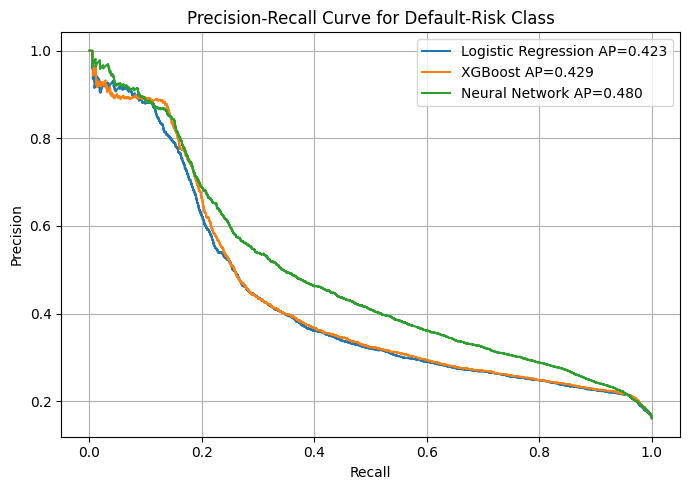

In [ ]:
import joblib
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, average_precision_score

# Load saved traditional models
lr_model = joblib.load("lr_l2_weights_model.pkl")
xgb_model = joblib.load("best_XGB_sampler_model.pkl")

plt.figure(figsize=(7, 5))

# Treat class 0 as the positive/default-risk class(class 1)
y_test_class0 = (y_test == 0).astype(int)

# ============================================================
# Logistic Regression and XGBoost
# ============================================================

models = {
    "Logistic Regression": lr_model,
    "XGBoost": xgb_model
}

for name, model in models.items():

    proba = model.predict_proba(X_test_fe)

    # Get probability of class 0
    class_0_index = list(model.classes_).index(0)
    y_score = proba[:, class_0_index]

    precision, recall, thresholds = precision_recall_curve(
        y_test_class0,
        y_score
    )
    #Calculates the precision and recall of many different thresholds

    #Summarizes the precision and recall curve into 1 number
    ap = average_precision_score(y_test_class0, y_score)

    plt.plot(recall, precision, label=f"{name} AP={ap:.3f}")


# ============================================================
# Neural Network
# ============================================================

# You already created this in your NN block:
# test_pd_nn = nn_pipe.predict_proba(X_test_fe)[:, 0]

nn_y_score = test_pd_nn

precision, recall, thresholds = precision_recall_curve(
    y_test_class0,
    nn_y_score
)

ap = average_precision_score(y_test_class0, nn_y_score)

plt.plot(recall, precision, label=f"Neural Network AP={ap:.3f}")


# ============================================================
# Final plot
# ============================================================

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve for Default-Risk Class")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# AP is perfect between 0 and 1 with 1 being perfect the higher the AP the better at finding the default classes